# In-silico chromatin perturbation of transcription regulators (ATAC → RNA)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/experimental/tf_perturbation_multiome.ipynb)

> **Experimental.** This notebook asks a trained model "what RNA would you predict if these peaks were
> closed?". The answer describes what the **model** learned to associate between accessibility and
> expression. It is a hypothesis generator, not a measurement of a causal perturbation, and it has not
> been validated against CRISPR or knockout data. Every effect below is therefore calibrated against
> random peak sets, and the notebook checks whether a second, independently trained model agrees.

The workflow, on 10x Multiome PBMCs:

1. Train a **peak-level** model: ATAC enters as binarized peaks with a Bernoulli decoder, so an edit is
   applied to named genomic regions rather than to LSI coordinates.
2. **Gate** the model: check alignment and ATAC → RNA prediction accuracy before trusting perturbations,
   and see how well each regulator's own expression is predicted.
3. Build peak sets for a panel of hematopoietic transcription regulators in two ways:
   **cis** (peaks around the regulator's own gene) and **motif** (peaks carrying its JASPAR motif).
4. Close each set with `predict_feature_perturbation(mode="off")`, decode RNA, and summarize the change
   per cell type.
5. Compare every effect with **frequency-matched random peak sets** (an empirical null).
6. Map the effects onto the genome: genome-wide effect maps, a chromosome ideogram, and an **in-silico
   tiling screen** that closes every peak around each regulator one at a time.
7. Look at latent shifts, dose-response, a combination of two regulators, and agreement with the LSI
   model used in the paper.

**Runtime.** On a Colab GPU, training takes a few minutes per model. The optional motif scan
downloads the hg38 genome from UCSC (about 940 MB) and streams through it once, which takes several
minutes; set `RUN_MOTIF_SCAN = False` below to skip it.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.2" "pandas==2.2.3" "pyjaspar>=3"

In [2]:
import gzip
import os
import re
import urllib.request
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from IPython.display import display

import univi
import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import cross_modal_predict, encode_adata, evaluate_alignment, pearson_corr_per_feature
from univi.perturbation import predict_feature_perturbation
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.2.0 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All settings are in one cell. `TF_PANEL` lists regulators with well-described roles in blood cells;
regulators missing from the data are dropped automatically.

In [3]:
N_EPOCHS = 400            # upper bound; early stopping usually ends sooner
BATCH_SIZE = 256
N_HVG = 2000              # highly variable genes (the panel regulators are always added)
N_PEAKS = 30000           # most frequently open peaks in training cells (cis peaks are always added)
N_LSI = 101               # LSI components for the comparison model
ATAC_RECON_WEIGHT = 0.1   # the Bernoulli term sums over ~15x more features than RNA; tune if needed
TF_PANEL = ["SPI1", "CEBPA", "CEBPB", "IRF8", "PAX5", "EBF1", "TCF7", "LEF1", "TBX21", "EOMES"]
CIS_WINDOW_BP = 50_000    # peaks within this distance of the regulator's TSS form its cis set
N_NULL = 50               # random peak sets per perturbation for the empirical null
RUN_MOTIF_SCAN = True     # needs pyjaspar and the hg38 genome (downloaded once)
GENOME_FASTA = None       # path to a local hg38 FASTA (.fa or .fa.gz); None downloads from UCSC
JASPAR_RELEASE = "JASPAR2024"
MOTIF_PEAK_PVALUE = 0.05  # length-corrected motif p-value of a whole peak (see Section 5)
MOTIF_TOP_PEAKS = 500     # strongest motif peaks kept per regulator, so set sizes are comparable
MASK_REPEATS = True       # treat soft-masked (lower-case) repeat sequence in the FASTA as N
Z_MIN = 3.0               # |z| needed before an effect is ranked by its size
N_NULL_LSI = 10           # random peak sets for the null of the LSI comparison model
OUTPUT_DIR = "univi_outputs"   # files written by this notebook go here
# Immediate-early / dissociation-response genes (see Section 8); flagged with * in rankings
TILING_WINDOW_BP = 250_000 # the in-silico tiling screen closes every peak within this distance of a TSS
N_TILING_NULL = 200       # random single peaks for the tiling screen's null
IEG_GENES = ["FOS", "FOSB", "JUN", "JUNB", "JUND", "EGR1", "EGR2", "EGR3", "IER2", "IER3", "IER5", "NR4A1",
             "NR4A2", "NR4A3", "ATF3", "DUSP1", "ZFP36", "KLF6", "HSPA1A", "HSPA1B", "DNAJB1", "CD69",
             "PPP1R15A", "TNFAIP3"]
RUN_LSI_COMPARISON = True # train the paper's LSI model and compare perturbation effects
USE_GENCODE_TSS = False   # True: take TSS from GENCODE v32 instead of the coordinates stored in rna.var

## 1. Data and split

The Multiome RNA file stores gene coordinates in `.var` (`chrom`, `chromStart`, `chromEnd`,
`strand`), and the ATAC file stores peak coordinates. We use them to link regulators to peaks.

In [4]:
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)
print({k: len(v) for k, v in splits.items()})
print("RNA .var columns:", list(rna.var.columns)[:12], "...")
print("ATAC .var columns:", list(atac.var.columns))

{'train': 7698, 'val': 956, 'test': 977}
RNA .var columns: ['gene_ids', 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb'] ...
ATAC .var columns: ['feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'n_counts']


### Gene TSS and peak coordinates

The TSS is `chromStart` for `+`-strand genes and `chromEnd` for `-`-strand genes. If the columns are
missing (or `USE_GENCODE_TSS = True`), gene coordinates come from the GENCODE v32 primary-assembly GTF,
the annotation of the 10x GRCh38-2020-A reference that Cell Ranger ARC uses. Print the table and check a
few genes you know before continuing.

In [5]:
GENCODE_GTF = ("https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_32/"
               "gencode.v32.primary_assembly.annotation.gtf.gz")
CACHE = uds.get_data_dir() / "annotation"
CACHE.mkdir(parents=True, exist_ok=True)


def download(url, dest):
    dest = Path(dest)
    if not dest.exists():
        print(f"downloading {url}")
        tmp = dest.with_suffix(dest.suffix + ".part")
        urllib.request.urlretrieve(url, tmp)
        tmp.rename(dest)
    return dest


def tss_from_var(var):
    need = ["chrom", "chromStart", "chromEnd", "strand"]
    if not set(need) <= set(var.columns):
        return None
    v = var[need].dropna()
    v = v[v["strand"].astype(str).isin(["+", "-"])]
    if v.empty:
        return None
    tss = np.where(v["strand"].astype(str) == "-", v["chromEnd"], v["chromStart"]).astype(np.int64)
    return pd.DataFrame({"chrom": v["chrom"].astype(str).to_numpy(), "tss": tss,
                         "strand": v["strand"].astype(str).to_numpy()}, index=v.index)


def tss_from_gencode(url=GENCODE_GTF):
    path = download(url, CACHE / Path(url).name)
    rows = []
    with gzip.open(path, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.split("\t", 8)
            if f[2] != "gene":
                continue
            name = re.search(r'gene_name "([^"]+)"', f[8]).group(1)
            start, end = int(f[3]) - 1, int(f[4])          # GTF is 1-based; store 0-based starts
            rows.append((name, f[0], end if f[6] == "-" else start, f[6]))
    df = pd.DataFrame(rows, columns=["gene", "chrom", "tss", "strand"])
    return df.drop_duplicates("gene").set_index("gene")


def peak_table(adata):
    if {"chrom", "chromStart", "chromEnd"} <= set(adata.var.columns):
        v = adata.var
        return pd.DataFrame({"chrom": v["chrom"].astype(str).to_numpy(),
                             "start": v["chromStart"].astype(np.int64).to_numpy(),
                             "end": v["chromEnd"].astype(np.int64).to_numpy()}, index=adata.var_names)
    parts = adata.var_names.to_series().str.extract(r"^(.+?)[:\-_](\d+)[\-_](\d+)$")
    if parts.isna().any().any():
        raise ValueError("Could not parse peak coordinates from var_names.")
    return pd.DataFrame({"chrom": parts[0].to_numpy(), "start": parts[1].astype(np.int64).to_numpy(),
                         "end": parts[2].astype(np.int64).to_numpy()}, index=adata.var_names)


tss = None if USE_GENCODE_TSS else tss_from_var(rna.var)
tss_source = "rna.var"
if tss is None:
    tss, tss_source = tss_from_gencode(), "GENCODE v32"
peaks_all = peak_table(atac)
print(f"TSS for {len(tss):,} genes from {tss_source}; {len(peaks_all):,} peaks")
shared_chroms = set(tss["chrom"]) & set(peaks_all["chrom"])
assert shared_chroms, "Gene and peak chromosome names do not match (e.g. 'chr1' vs '1')."

panel = [g for g in TF_PANEL if g in rna.var_names and g in tss.index]
print("regulators used:", panel, "| dropped:", sorted(set(TF_PANEL) - set(panel)))
tss.loc[panel]

TSS for 29,095 genes from rna.var; 107,194 peaks
regulators used: ['SPI1', 'CEBPA', 'CEBPB', 'IRF8', 'PAX5', 'EBF1', 'TCF7', 'LEF1', 'TBX21', 'EOMES'] | dropped: []


,chrom,tss,strand
genes,,,
SPI1,chr11,47378547,-
CEBPA,chr19,33302534,-
CEBPB,chr20,50190829,+
IRF8,chr16,85899161,+
PAX5,chr9,37034268,-
EBF1,chr5,159099916,-
TCF7,chr5,134114680,+
LEF1,chr4,108168956,-
TBX21,chr17,47733235,+


## 2. Features: genes and peaks

RNA features are the training-set HVGs plus every panel regulator, kept as log-normalized expression
(not z-scored), so predicted changes read in log1p(CP10k) units. ATAC features are the `N_PEAKS` peaks
open in the most training cells, plus every peak within `CIS_WINDOW_BP` of a regulator's TSS, binarized
(open = 1). Everything is fit on training cells only.

In [6]:
def peaks_near(tss_row, peaks, window):
    same = peaks["chrom"].to_numpy() == tss_row["chrom"]
    mid = (peaks["start"].to_numpy() + peaks["end"].to_numpy()) // 2
    return peaks.index[same & (np.abs(mid - int(tss_row["tss"])) <= window)]


hvg = RNAPreprocessor(n_hvg=N_HVG).fit(rna[splits["train"]]).features_
genes = list(dict.fromkeys(hvg + panel))
rna_prep = RNAPreprocessor(n_hvg=None, scale=False).fit(rna[splits["train"]][:, genes])

train_counts = atac[splits["train"]].layers["counts"]
peak_freq = pd.Series(np.asarray((train_counts > 0).mean(axis=0)).ravel(), index=atac.var_names)
cis_all = {tf: peaks_near(tss.loc[tf], peaks_all, CIS_WINDOW_BP) for tf in panel}
top_peaks = peak_freq[peak_freq > 0].sort_values(ascending=False).index[:N_PEAKS]
model_peaks = list(dict.fromkeys(list(top_peaks) + [p for ps in cis_all.values() for p in ps
                                                    if peak_freq[p] > 0]))
peak_idx = atac.var_names.get_indexer(model_peaks)


def binarize(adata_counts):
    x = sp.csr_matrix(adata_counts.layers["counts"][:, peak_idx], dtype=np.float32)
    x.data = np.ones_like(x.data)
    return ad.AnnData(x, obs=adata_counts.obs.copy(), var=peaks_all.loc[model_peaks].copy())


parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": binarize(atac[i])} for k, i in splits.items()}
train, val, test = parts["train"], parts["val"], parts["test"]
print("RNA", train["rna"].shape, "| ATAC", train["atac"].shape)

RNA (7698, 2003) | ATAC (7698, 30105)


## 3. Train the peak-level model

Settings follow the quickstart. `ATAC_RECON_WEIGHT` scales the Bernoulli term, which sums over many more
features than the RNA term; 0.1 is a starting value, not a tuned one.

In [7]:
cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[
        ModalityConfig("rna", train["rna"].n_vars, [512, 256, 128], [128, 256, 512], likelihood="gaussian"),
        ModalityConfig("atac", train["atac"].n_vars, [512, 256, 128], [128, 256, 512], likelihood="bernoulli",
                       recon_weight=ATAC_RECON_WEIGHT),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
train_cfg = TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
                           early_stopping=True, patience=50, best_epoch_warmup=110, log_every=50)
trainer = UniVITrainer(model, make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
                       make_loader(val, batch_size=1024), train_cfg)
history = trainer.fit()
print("best epoch:", trainer.best_epoch)

[2026-09-22 20:29:10,691] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-22 20:29:10,692] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-22 20:29:10,692] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-22 20:29:10,693] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-22 20:29:10,693] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-22 20:29:10,694] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-22 20:29:10,694] [UniVITrainer] [INFO]   log_every: 50
[2026-09-22 20:29:10,694] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-22 20:29:10,695] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-22 20:29:10,695] [UniVITrainer] [INFO]   seed: 0
[2026-09-22 20:29:10,695] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-22 20:29:10,696] [UniVITrainer] [INFO]   patience: 50
[2026-09-22 20:29:10,696] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-22 20:29:10,696] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-22 20:29:13,921] [Uni

best epoch: 110


## 4. Gate the model before perturbing it

A perturbation readout can only be as good as the model's ATAC → RNA mapping. We check paired-cell
alignment on held-out cells, then per-gene accuracy of RNA predicted from ATAC alone. The regulators'
own prediction accuracy is printed separately: if a regulator's expression is poorly predicted from
chromatin, its perturbation results deserve little weight.

FOSCTTM (lower is better)    0.032
Recall@10                    0.475
label transfer RNA->ATAC     0.890
dtype: float64


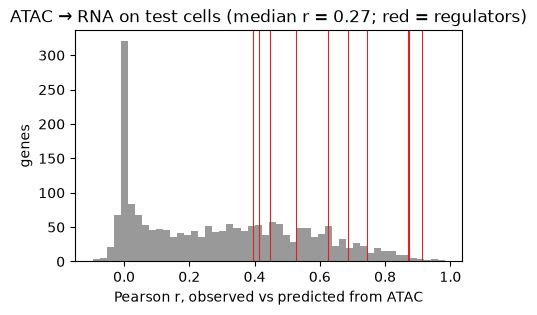

,pearson_r_from_atac,expressed_in_top_type
genes,,
SPI1,0.688,cDC
CEBPA,0.526,CD16 Mono
CEBPB,0.414,CD16 Mono
IRF8,0.626,pDC
PAX5,0.913,Memory B
EBF1,0.869,Naive B
TCF7,0.746,CD4 Naive
LEF1,0.872,CD8 Naive
TBX21,0.395,NK


In [8]:
z_rna = encode_adata(model, test["rna"], modality="rna", device=device, latent="modality_mean")
z_atac = encode_adata(model, test["atac"], modality="atac", device=device, latent="modality_mean")
labels = test["rna"].obs["cell_type"].astype(str).to_numpy()
m = evaluate_alignment(Z1=z_rna, Z2=z_atac, labels_source=labels, labels_target=labels, recall_ks=(1, 10))
print(pd.Series({"FOSCTTM (lower is better)": m["foscttm_mean"],
                 "Recall@10": m["recall_at_k"]["10"]["mean"],
                 "label transfer RNA->ATAC": m["label_transfer_acc"]}).round(3))

baseline = cross_modal_predict(model, test["atac"], src_mod="atac", tgt_mod="rna", device=device)
observed = dense(test["rna"].X)
gene_r = pd.Series(pearson_corr_per_feature(observed, baseline), index=test["rna"].var_names)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(gene_r.dropna(), bins=50, color="0.6")
for tf in panel:
    ax.axvline(gene_r[tf], lw=0.8, color="C3")
ax.set(xlabel="Pearson r, observed vs predicted from ATAC", ylabel="genes",
       title=f"ATAC → RNA on test cells (median r = {gene_r.median():.2f}; red = regulators)")
plt.show()
gate = gene_r.loc[panel].rename("pearson_r_from_atac").to_frame()
gate["expressed_in_top_type"] = [
    pd.Series(observed[:, test["rna"].var_names.get_loc(tf)], index=labels).groupby(level=0).mean().idxmax()
    for tf in panel]
gate.round(3)

A shared latent embedding of the test cells is used for plotting below.

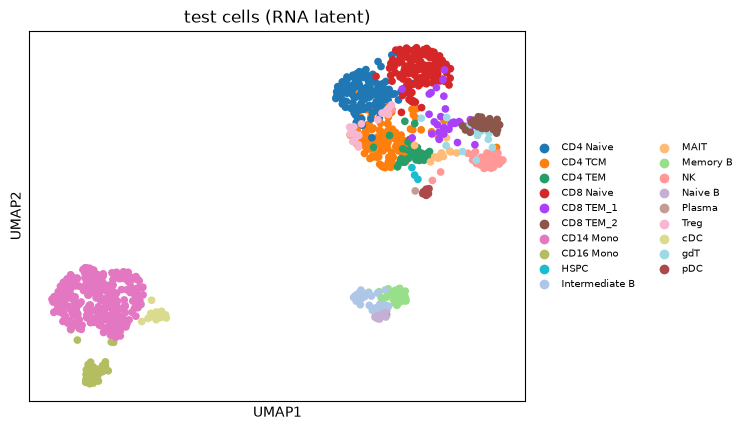

In [9]:
test_rna = test["rna"]
test_rna.obsm["X_univi"] = z_rna
sc.pp.neighbors(test_rna, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(test_rna, random_state=0)
sc.pl.umap(test_rna, color="cell_type", legend_fontsize=7, title="test cells (RNA latent)")

## 5. Peak sets for each regulator

### Cis: peaks around the regulator's own gene

Closing the chromatin around a gene is the most direct perturbation the model can see. The expected
first-order readout is a drop in that gene's predicted expression, in the cell types that express it.

Expect these effects to be **small**. UniVI has no gene-specific path from a peak to a gene: every edit
passes through the shared latent space (30 dimensions here), so closing a handful of peaks changes a
gene's prediction only as far as it changes the model's view of the whole cell state. A cis readout
therefore measures how much the peaks around a regulator inform cell state, not cis regulation itself.

In [10]:
peak_sets = {}
for tf in panel:
    cis = [p for p in cis_all[tf] if p in set(model_peaks)]
    if cis:
        peak_sets[(tf, "cis")] = cis
pd.Series({tf: len(peak_sets.get((tf, "cis"), [])) for tf in panel}, name="cis peaks in model").to_frame().T

,SPI1,CEBPA,CEBPB,IRF8,PAX5,EBF1,TCF7,LEF1,TBX21,EOMES
cis peaks in model,22,16,22,24,14,8,18,15,14,6


### Motif: peaks carrying the regulator's binding motif (optional)

Each model peak is scanned on both strands with the regulator's JASPAR position weight matrix. Its best
window is first converted to a **window p-value**: the probability that one random window scores at
least as high, computed exactly from the matrix under the base composition of the scanned peaks. Window
p-values are comparable across matrices of different widths, which relative scores are not.

A long peak has more windows, so it is more likely to contain a strong match by chance. The window
p-value is therefore turned into a **peak p-value** with the Šidák correction for the number of windows
tested, `p_peak = 1 - (1 - p_window)^n_windows` (both strands). Overlapping windows are correlated, so
this is conservative. Peaks with `p_peak ≤ MOTIF_PEAK_PVALUE` qualify, and the `MOTIF_TOP_PEAKS`
strongest are kept so that every regulator gets a set of similar size.

For each regulator the scan prints how many peaks qualify and how many would qualify **by chance**
(`MOTIF_PEAK_PVALUE` × number of peaks). A short matrix cannot reach a small peak-level p-value even with
a perfect site (a given 8-mer occurs by chance in about 1.5% of 500-bp sequences), so a regulator whose
count is close to the chance count has no motif set that can be told apart from random matches; it is
flagged and its motif results should not be interpreted.

The UCSC hg38 FASTA marks repeats (RepeatMasker and Tandem Repeats Finder) in lower case. With
`MASK_REPEATS = True` those bases are treated as N, which removes matches in microsatellites such as
GGAA repeats (strong spurious ETS matches) at the cost of also removing genuine sites inside repeats.
The background is still a simple independent-base model, so treat p-values as a ranking, not as exact
error rates.

A motif match is a weak proxy for binding: members of a family share motifs (for example ETS factors
with SPI1, T-box factors TBX21 and EOMES, C/EBP family members), so a "motif" perturbation is better
read as "sites of this motif family".

In [11]:
def load_log_odds(tfs, release=JASPAR_RELEASE, pseudocount=0.8):
    from pyjaspar import jaspardb
    jdb = jaspardb(release=release)
    out = {}
    for tf in tfs:
        motifs = jdb.fetch_motifs_by_name(tf)
        if not motifs:
            print(f"  no {release} motif named {tf}; skipped")
            continue
        m = motifs[0]
        counts = np.array([m.counts[b] for b in "ACGT"], dtype=float).T          # (width, 4)
        probs = (counts + pseudocount / 4) / (counts.sum(1, keepdims=True) + pseudocount)
        out[tf] = (m.matrix_id, np.log2(probs / 0.25))
    return out


def iter_fasta(path, keep):
    """Yield (chromosome, sequence bytes with case preserved) for the chromosomes in `keep`, one at a time."""
    opener = gzip.open if str(path).endswith(".gz") else open
    name, chunks = None, []
    with opener(path, "rb") as fh:
        for line in fh:
            if line.startswith(b">"):
                if name in keep:
                    yield name, b"".join(chunks)
                name, chunks = line[1:].split()[0].decode(), []
            elif name in keep:
                chunks.append(line.rstrip())
    if name in keep:
        yield name, b"".join(chunks)


LOOKUP_ANY = np.full(256, 4, dtype=np.int8)      # case-insensitive: A C G T -> 0..3, anything else -> N
for i, b in enumerate(b"ACGT"):
    LOOKUP_ANY[b] = i
    LOOKUP_ANY[b + 32] = i                           # lower case
LOOKUP_SCAN = LOOKUP_ANY.copy()
if MASK_REPEATS:
    LOOKUP_SCAN[[b + 32 for b in b"ACGT"]] = 4       # soft-masked repeats -> N


def best_scores(seq_codes, pwms):
    """Best log-odds window score (both strands) and number of N-free windows, per motif."""
    out = {}
    for tf, (lo, lo_rc) in pwms.items():
        w = lo.shape[0]
        if len(seq_codes) < w:
            out[tf] = (-np.inf, 0)
            continue
        win = np.lib.stride_tricks.sliding_window_view(seq_codes, w)
        n_valid = int((win.max(1) < 4).sum())
        if n_valid == 0:
            out[tf] = (-np.inf, 0)
            continue
        cols = np.arange(w)
        out[tf] = (max(lo[cols, win].sum(1).max(), lo_rc[cols, win].sum(1).max()), n_valid)
    return out


def score_tail(lo, background, resolution=100):
    """Exact P(window score >= s) under an i.i.d. background, via dynamic programming on rounded scores."""
    q = np.round(lo * resolution).astype(np.int64)
    offset = q.min(1)
    dist = np.array([1.0])
    for row, low in zip(q, offset):
        new = np.zeros(len(dist) + int((row - low).max()))
        for base in range(4):
            k = int(row[base] - low)
            new[k:k + len(dist)] += background[base] * dist
        dist = new
    tail = np.cumsum(dist[::-1])[::-1]

    def p_window(s):
        s = np.asarray(s, dtype=float)
        out = np.ones_like(s)
        ok = np.isfinite(s)
        k = np.ceil(s[ok] * resolution - 1e-9).astype(np.int64) - offset.sum()
        out[ok] = tail[np.clip(k, 0, len(tail) - 1)]
        return out

    return p_window


def scan_peaks(peaks, log_odds, fasta):
    """Length-corrected motif p-value per peak and regulator, and each peak's GC fraction."""
    pwms = {}
    for tf, (_, lo) in log_odds.items():
        pwms[tf] = (np.hstack([lo, np.full((lo.shape[0], 1), -1e3)]),            # column 4: N
                    np.hstack([lo[::-1, ::-1], np.full((lo.shape[0], 1), -1e3)]))  # reverse complement
    tfs = list(pwms)
    best = np.full((len(peaks), len(tfs)), -np.inf)
    n_windows = np.zeros((len(peaks), len(tfs)))
    gc = np.full(len(peaks), np.nan)
    base_counts = np.zeros(5)
    pos = pd.Series(np.arange(len(peaks)), index=peaks.index)
    by_chrom = {c: df for c, df in peaks.groupby("chrom")}
    seen = set()
    for chrom, seq in iter_fasta(fasta, set(by_chrom)):
        raw = np.frombuffer(seq, dtype=np.uint8)
        codes, codes_any = LOOKUP_SCAN[raw], LOOKUP_ANY[raw]
        df = by_chrom[chrom]
        for row_i, start, end in zip(pos[df.index].to_numpy(), df["start"].to_numpy(), df["end"].to_numpy()):
            window = codes[start:end]
            base_counts += np.bincount(window, minlength=5)
            acgt = np.bincount(codes_any[start:end], minlength=5)[:4]
            gc[row_i] = (acgt[1] + acgt[2]) / max(acgt.sum(), 1)
            b = best_scores(window, pwms)
            best[row_i] = [b[tf][0] for tf in tfs]
            n_windows[row_i] = [2 * b[tf][1] for tf in tfs]     # both strands
        seen.add(chrom)
    missing = set(by_chrom) - seen
    if missing:
        print(f"  chromosomes not in the FASTA (their peaks get p = 1): {sorted(missing)}")
    background = base_counts[:4] / base_counts[:4].sum()
    print(f"  peak base composition (A, C, G, T): {np.round(background, 3)}; "
          f"{base_counts[4] / base_counts.sum():.1%} of peak bases masked or N")
    pvals = np.ones_like(best)
    for j, tf in enumerate(tfs):
        p_win = score_tail(log_odds[tf][1], background)(best[:, j])
        pvals[:, j] = -np.expm1(n_windows[:, j] * np.log1p(-np.minimum(p_win, 1 - 1e-16)))   # Šidák
        pvals[n_windows[:, j] == 0, j] = 1.0
    return (pd.DataFrame(pvals, index=peaks.index, columns=tfs),
            pd.Series(gc, index=peaks.index, name="gc"))


motif_pvals, peak_gc = None, None
if RUN_MOTIF_SCAN:
    log_odds = load_log_odds(panel)
    print({tf: mid for tf, (mid, _) in log_odds.items()})
    fasta = GENOME_FASTA or download("https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz",
                                     CACHE / "hg38.fa.gz")
    motif_pvals, peak_gc = scan_peaks(peaks_all.loc[model_peaks], log_odds, fasta)
    for tf in motif_pvals.columns:
        pv = motif_pvals[tf]
        chosen = pv[pv <= MOTIF_PEAK_PVALUE].sort_values(kind="stable").index[:MOTIF_TOP_PEAKS]
        n_pass, n_chance = int((pv <= MOTIF_PEAK_PVALUE).sum()), MOTIF_PEAK_PVALUE * len(pv)
        flag = "  <- not clearly above chance; do not interpret" if n_pass < 2 * n_chance else ""
        print(f"{tf}: {n_pass:,} of {len(pv):,} peaks at peak-level p <= {MOTIF_PEAK_PVALUE:g} "
              f"(chance ~{n_chance:,.0f}, ratio {n_pass / n_chance:.1f}); keeping {len(chosen)}{flag}")
        if len(chosen):
            peak_sets[(tf, "motif")] = list(chosen)
    width = peaks_all.loc[model_peaks, "end"] - peaks_all.loc[model_peaks, "start"]
    kept = {tf: width.loc[p].median() for (tf, kind), p in peak_sets.items() if kind == "motif"}
    print(f"median peak width: all model peaks {width.median():.0f} bp; kept motif peaks "
          + ", ".join(f"{tf} {w:.0f}" for tf, w in kept.items()))

pd.Series({f"{tf} ({kind})": len(p) for (tf, kind), p in peak_sets.items()}, name="peaks").to_frame().T

{'SPI1': 'MA0080.7', 'CEBPA': 'MA0102.5', 'CEBPB': 'MA0466.4', 'IRF8': 'MA0652.2', 'PAX5': 'MA0014.4', 'EBF1': 'MA0154.5', 'TCF7': 'MA0769.3', 'LEF1': 'MA0768.3', 'TBX21': 'MA0690.3', 'EOMES': 'MA0800.2'}
  chromosomes not in the FASTA (their peaks get p = 1): ['GL000195.1', 'GL000205.2', 'GL000219.1', 'KI270713.1']
  peak base composition (A, C, G, T): [0.231 0.269 0.269 0.231]; 27.1% of peak bases masked or N
SPI1: 10,317 of 30,105 peaks at peak-level p <= 0.05 (chance ~1,505, ratio 6.9); keeping 500
CEBPA: 2,303 of 30,105 peaks at peak-level p <= 0.05 (chance ~1,505, ratio 1.5); keeping 500  <- not clearly above chance; do not interpret
CEBPB: 239 of 30,105 peaks at peak-level p <= 0.05 (chance ~1,505, ratio 0.2); keeping 239  <- not clearly above chance; do not interpret
IRF8: 2,713 of 30,105 peaks at peak-level p <= 0.05 (chance ~1,505, ratio 1.8); keeping 500  <- not clearly above chance; do not interpret
PAX5: 149 of 30,105 peaks at peak-level p <= 0.05 (chance ~1,505, ratio 0.1

,SPI1 (cis),CEBPA (cis),CEBPB (cis),IRF8 (cis),PAX5 (cis),EBF1 (cis),TCF7 (cis),LEF1 (cis),TBX21 (cis),EOMES (cis),SPI1 (motif),CEBPA (motif),CEBPB (motif),IRF8 (motif),PAX5 (motif),EBF1 (motif),TCF7 (motif),LEF1 (motif),TBX21 (motif),EOMES (motif)
peaks,22,16,22,24,14,8,18,15,14,6,500,500,239,500,149,500,225,500,500,500


## 6. Close the peaks and decode RNA

`predict_feature_perturbation` edits the named ATAC inputs (here: set to 0, i.e. closed), runs the
original and edited inputs through the ATAC encoder and the RNA decoder, and returns both predictions
and their difference. Peaks that were already closed in a cell do not change that cell's input, so the
per-cell effect depends on how many of the set's peaks were open.

In [12]:
res = predict_feature_perturbation(model, test["atac"], source_modality="atac", target_modality="rna",
                                   features=peak_sets[next(iter(peak_sets))], mode="off", device=device)
assert peak_sets, "No peak sets were built; check the TSS/peak coordinate tables above."
assert np.allclose(res["baseline"], baseline, atol=1e-5)   # same inputs, same model: same baseline
cell_types = pd.Index(sorted(set(labels)))


def by_type(delta):
    """Mean predicted change per cell type (rows) and gene (columns)."""
    return pd.DataFrame(delta, index=labels, columns=test_rna.var_names).groupby(level=0).mean().loc[cell_types]


effects, deltas = {}, {}
for key, peaks in peak_sets.items():
    out = predict_feature_perturbation(model, test["atac"], source_modality="atac", target_modality="rna",
                                       features=peaks, mode="off", device=device)
    deltas[key] = out["delta"]
    effects[key] = by_type(out["delta"])
print(f"{len(effects)} perturbations; each is a cell types x genes table of mean predicted change")

20 perturbations; each is a cell types x genes table of mean predicted change


## 7. Empirical null: matched random peak sets

Closing any few hundred open peaks moves the latent space, and many genes move with almost any latent
shift, so the null is usually **not centered on zero**. To separate regulator-specific effects from
that, each perturbation is compared with `N_NULL` random peak sets of the same size, drawn to match the
real set's distribution of training-cell accessibility (ten bins), peak width (three bins) and, when the
motif scan has run, GC content (three bins). Motif-selected peaks differ from typical peaks in width and
GC, and a null that ignores this would credit those differences to the regulator. The null is computed
with a small helper that zeroes columns and decodes; the first check confirms that it reproduces
`predict_feature_perturbation` exactly.

In [13]:
X_test = sp.csr_matrix(test["atac"].X)
name_to_col = pd.Series(np.arange(len(model_peaks)), index=model_peaks)


def qbin(values, q):
    return pd.qcut(pd.Series(np.asarray(values)).rank(method="first"), q, labels=False).to_numpy()


width_model = (peaks_all.loc[model_peaks, "end"] - peaks_all.loc[model_peaks, "start"]).to_numpy()
stratum = qbin(peak_freq.loc[model_peaks], 10) * 3 + qbin(width_model, 3)
if peak_gc is not None:
    stratum = stratum * 3 + qbin(peak_gc.loc[model_peaks].fillna(peak_gc.median()), 3)
print(f"null strata: {len(np.unique(stratum))} (accessibility x width"
      f"{' x GC' if peak_gc is not None else ''})")


def closed_delta(cols):
    mask = np.ones(X_test.shape[1], dtype=np.float32)
    mask[cols] = 0.0
    edited = ad.AnnData(sp.csr_matrix(X_test.multiply(mask[None, :])), obs=test["atac"].obs)
    return cross_modal_predict(model, edited, src_mod="atac", tgt_mod="rna", device=device) - baseline


first = next(iter(peak_sets))
assert np.allclose(closed_delta(name_to_col[peak_sets[first]].to_numpy()), deltas[first], atol=1e-5)


def matched_random_sets(cols, n, rng):
    """Random peak sets with the same number of peaks as `cols` in every stratum (excluding `cols`)."""
    cols = np.asarray(cols)
    need = pd.Series(stratum[cols]).value_counts()
    pool = {b: np.setdiff1d(np.flatnonzero(stratum == b), cols) for b in need.index}
    short = [b for b, c in need.items() if len(pool[b]) < c]
    if short:
        print(f"  {len(short)} strata have fewer spare peaks than needed; sampling those with replacement")
    return [np.concatenate([rng.choice(pool[b], size=int(c), replace=len(pool[b]) < c) for b, c in need.items()])
            for _ in range(n)]


rng = np.random.default_rng(0)
null_mean, null_sd, zscores, null_self = {}, {}, {}, {}
for key, peaks in peak_sets.items():
    draws = np.stack([by_type(closed_delta(c)).to_numpy()
                      for c in matched_random_sets(name_to_col[peaks].to_numpy(), N_NULL, rng)])
    null_mean[key] = pd.DataFrame(draws.mean(0), index=cell_types, columns=test_rna.var_names)
    null_sd[key] = pd.DataFrame(draws.std(0, ddof=1), index=cell_types, columns=test_rna.var_names)
    s0 = null_sd[key].median(axis=1)                                  # one floor per cell type
    zscores[key] = (effects[key] - null_mean[key]).div(null_sd[key].add(s0, axis=0) + 1e-12)
    null_self[key] = pd.DataFrame(draws[:, :, test_rna.var_names.get_loc(key[0])], columns=cell_types)
    print(f"{key}: null done")
excess = {key: effects[key] - null_mean[key] for key in peak_sets}   # effect beyond the matched null

null strata: 87 (accessibility x width x GC)
('SPI1', 'cis'): null done
('CEBPA', 'cis'): null done
('CEBPB', 'cis'): null done
('IRF8', 'cis'): null done
('PAX5', 'cis'): null done
('EBF1', 'cis'): null done
('TCF7', 'cis'): null done
('LEF1', 'cis'): null done
('TBX21', 'cis'): null done
('EOMES', 'cis'): null done
('SPI1', 'motif'): null done
('CEBPA', 'motif'): null done
('CEBPB', 'motif'): null done
('IRF8', 'motif'): null done
('PAX5', 'motif'): null done
('EBF1', 'motif'): null done
('TCF7', 'motif'): null done
('LEF1', 'motif'): null done
('TBX21', 'motif'): null done
('EOMES', 'motif'): null done


Two quantities are used from here on, for every cell type and gene:

- the **excess effect**, `observed - null mean`: how much more the gene moves than it does when random
  matched peaks are closed;
- a **moderated z-score**, `excess / (null s.d. + s0)`, where `s0` is the median null s.d. of all genes
  in that cell type. Without `s0` (the "fudge factor" of SAM, Tusher et al. 2001), genes whose predicted
  expression barely varies get enormous z-scores for negligible changes and dominate every ranking.

Genes are ranked by the size of their excess effect among those with |z| ≥ `Z_MIN`. With `N_NULL = 50`
the null is estimated from 50 draws; treat z as a screening statistic rather than an exact p-value.
The next plot shows the null for each regulator's own gene in the cell type that expresses it most, with
the observed effect as a red line.

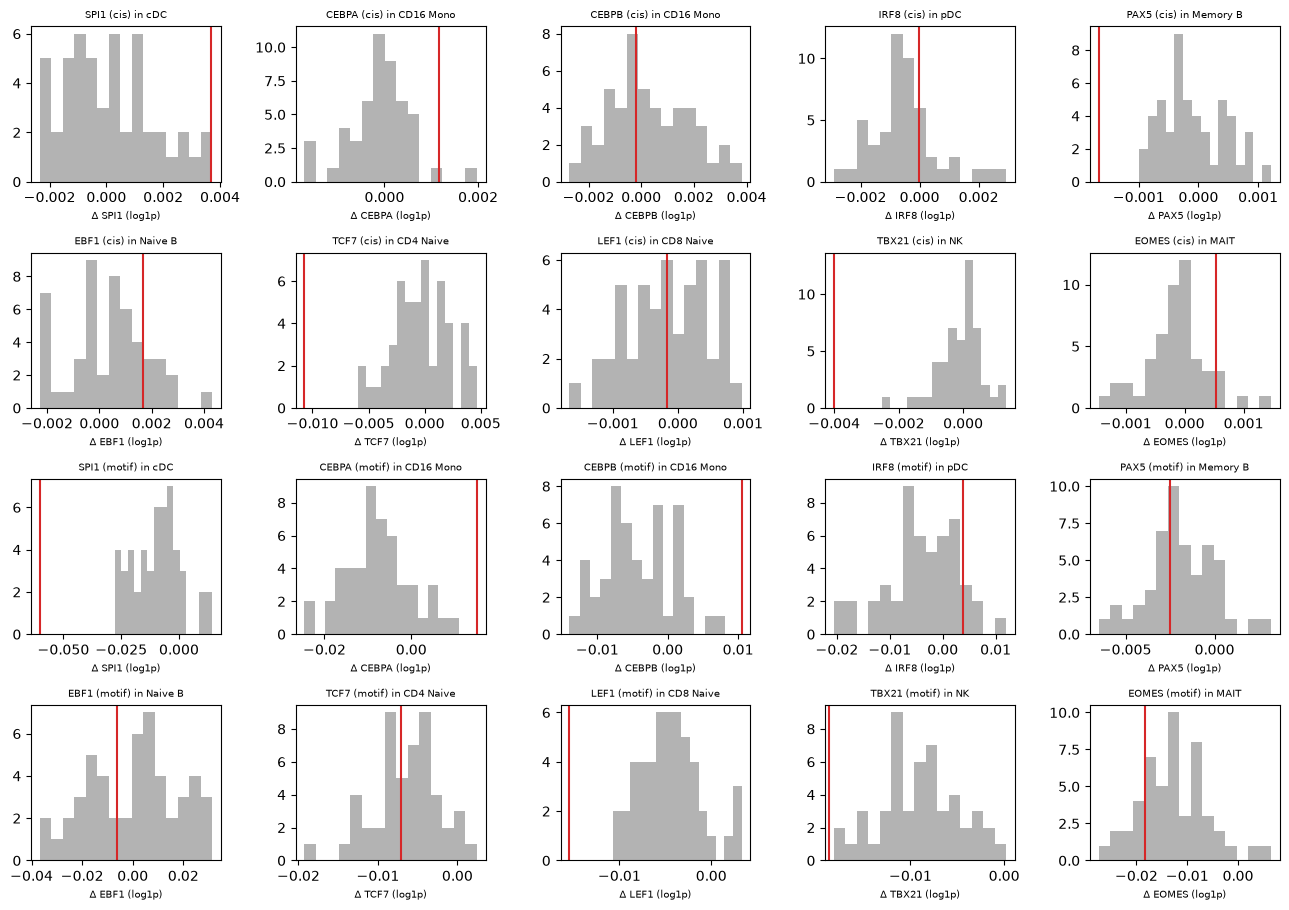

In [14]:
keys = list(peak_sets)
ncol = min(5, len(keys))
fig, axes = plt.subplots(int(np.ceil(len(keys) / ncol)), ncol, figsize=(2.6 * ncol, 2.3 * np.ceil(len(keys) / ncol)),
                         squeeze=False)
for ax, key in zip(axes.ravel(), keys):
    tf, ct = key[0], gate.loc[key[0], "expressed_in_top_type"]
    ax.hist(null_self[key][ct], bins=15, color="0.7")
    ax.axvline(effects[key].loc[ct, tf], color="C3")
    ax.set_title(f"{tf} ({key[1]}) in {ct}", fontsize=7)
    ax.set_xlabel(f"Δ {tf} (log1p)", fontsize=7)
for ax in axes.ravel()[len(keys):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. What moved

### The regulator's own expression

Rows are perturbations, columns are cell types; color is the excess change in the regulator's own
predicted expression (beyond the matched null) and dots mark |z| ≥ `Z_MIN`. For cis sets, a negative
value where the regulator is expressed is the expected direction.

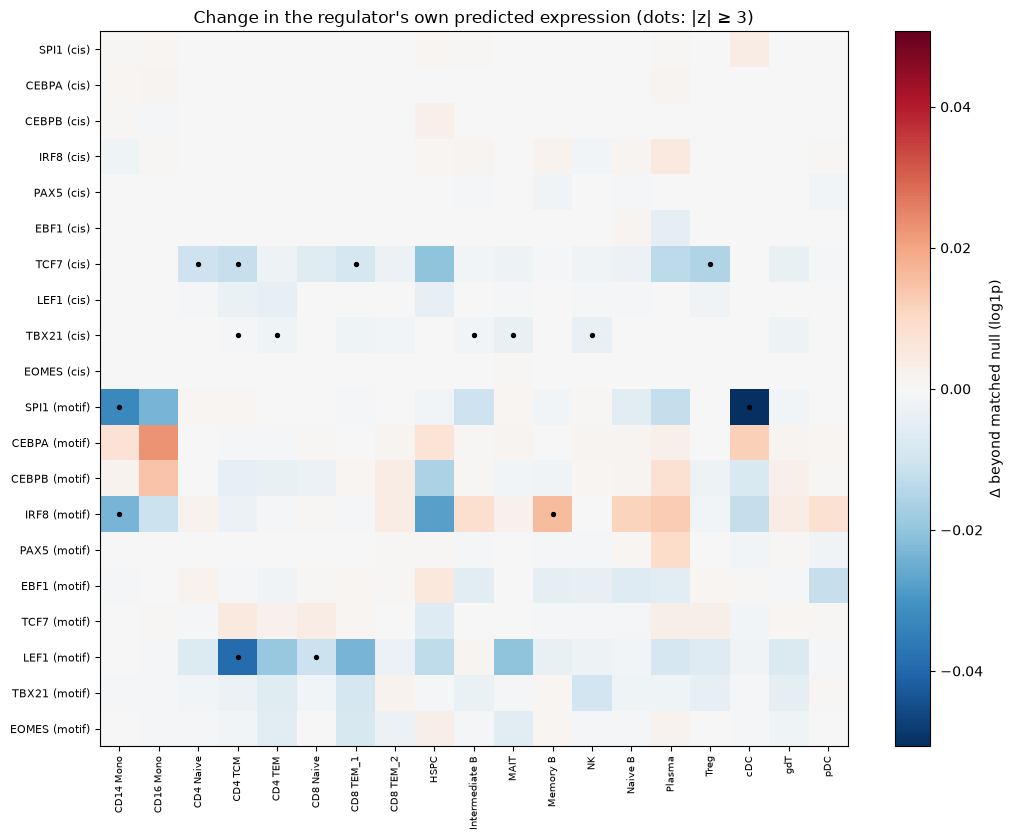

In [15]:
self_excess = pd.DataFrame({f"{tf} ({kind})": excess[(tf, kind)][tf] for (tf, kind) in peak_sets}).T
self_z = pd.DataFrame({f"{tf} ({kind})": zscores[(tf, kind)][tf] for (tf, kind) in peak_sets}).T
fig, ax = plt.subplots(figsize=(0.45 * len(cell_types) + 2, 0.35 * len(self_excess) + 1.5))
lim = np.nanmax(np.abs(self_excess.to_numpy())) or 1.0
im = ax.imshow(self_excess.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
yy, xx = np.nonzero(np.abs(self_z.to_numpy()) >= Z_MIN)
ax.scatter(xx, yy, s=8, c="k")
ax.set_xticks(range(len(cell_types)), cell_types, rotation=90, fontsize=7)
ax.set_yticks(range(len(self_excess)), self_excess.index, fontsize=8)
plt.colorbar(im, ax=ax, label="Δ beyond matched null (log1p)")
ax.set_title(f"Change in the regulator's own predicted expression (dots: |z| ≥ {Z_MIN:g})")
plt.tight_layout()
plt.show()

### Genes that respond beyond the null

For each perturbation, genes are ranked by their largest excess effect over the cell types in which
they pass |z| ≥ `Z_MIN`, and the excess effect of the top genes is shown in every cell type. Genes are
the rows; dots mark |z| ≥ `Z_MIN`.

('SPI1', 'cis'): no gene passes |z| >= 3


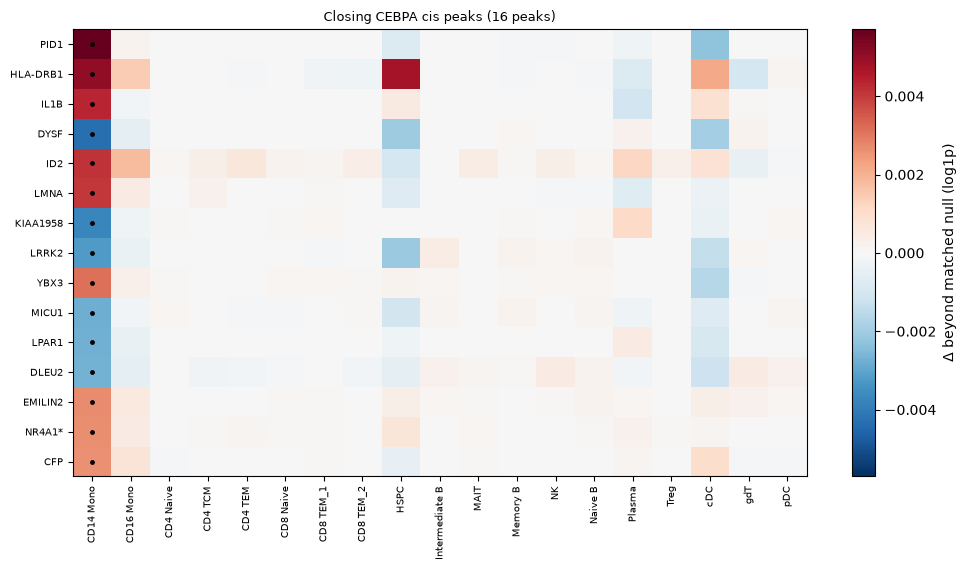

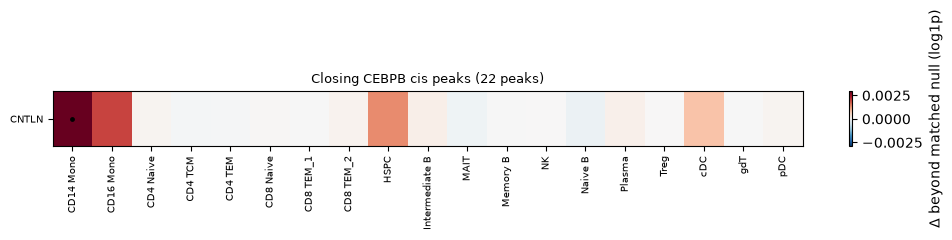

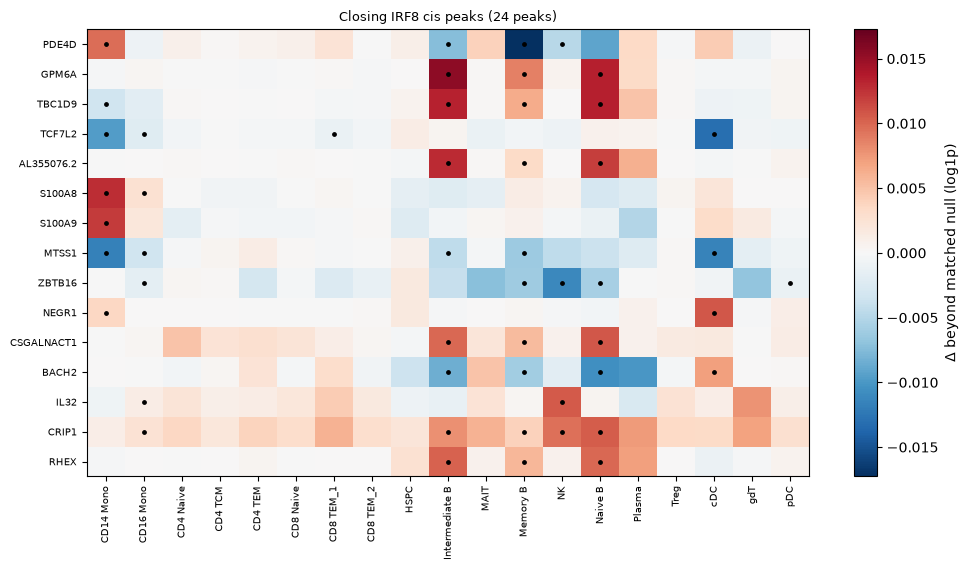

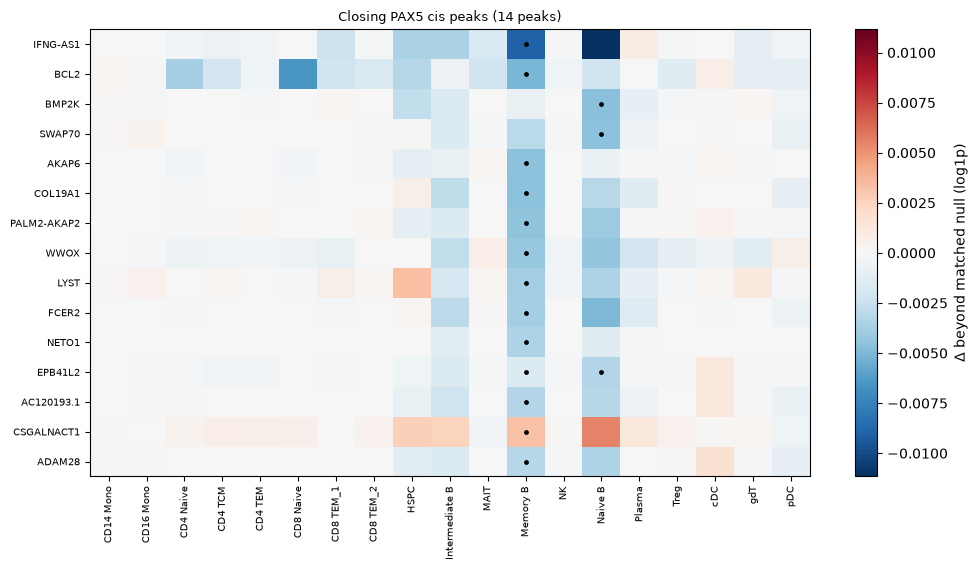

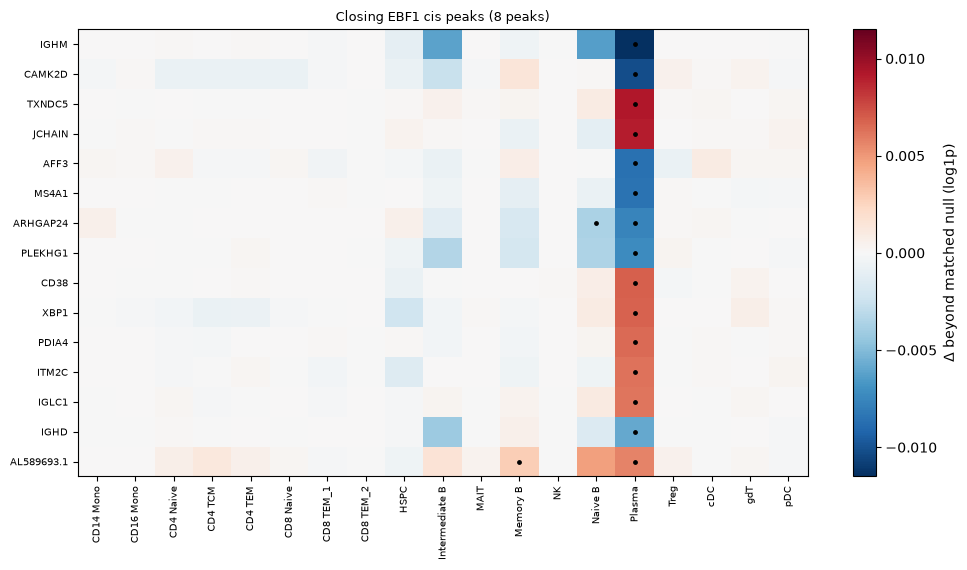

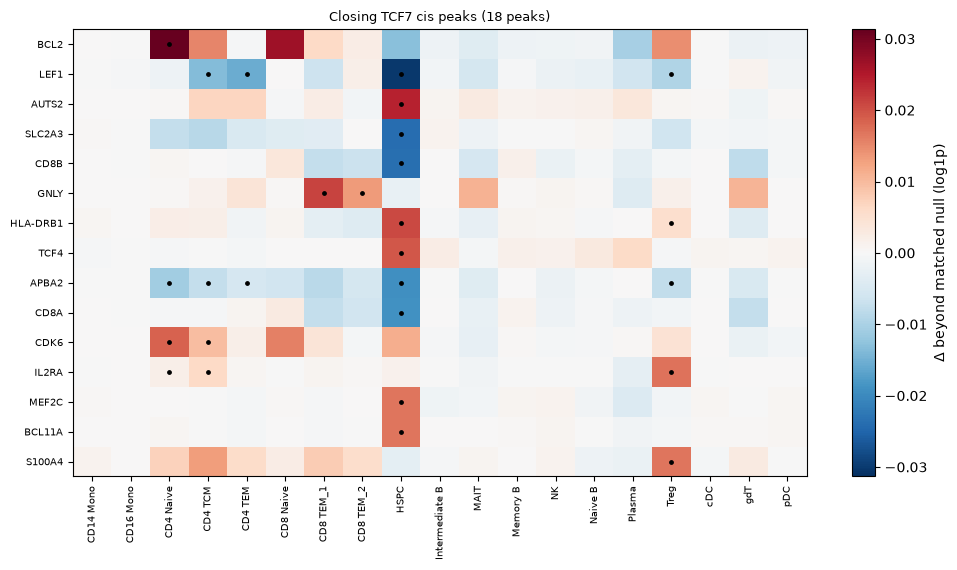

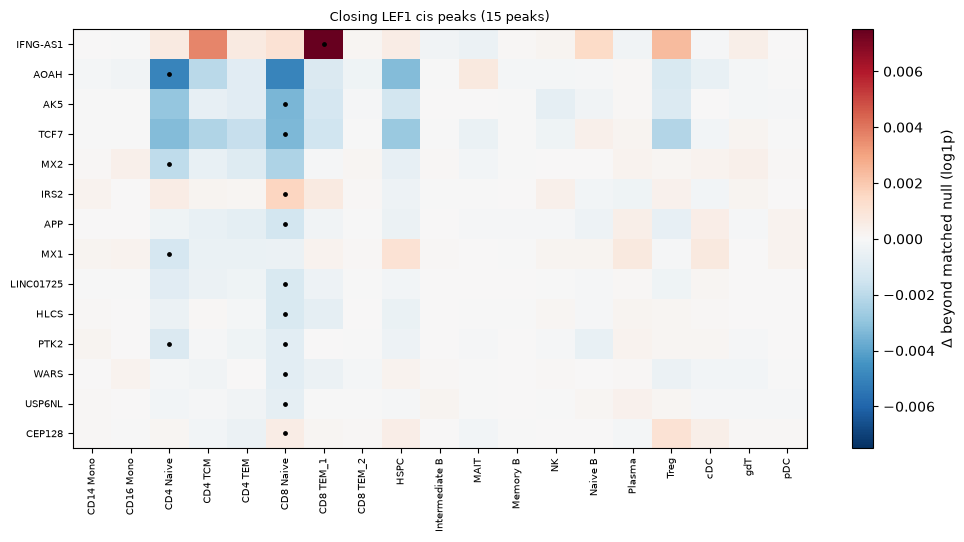

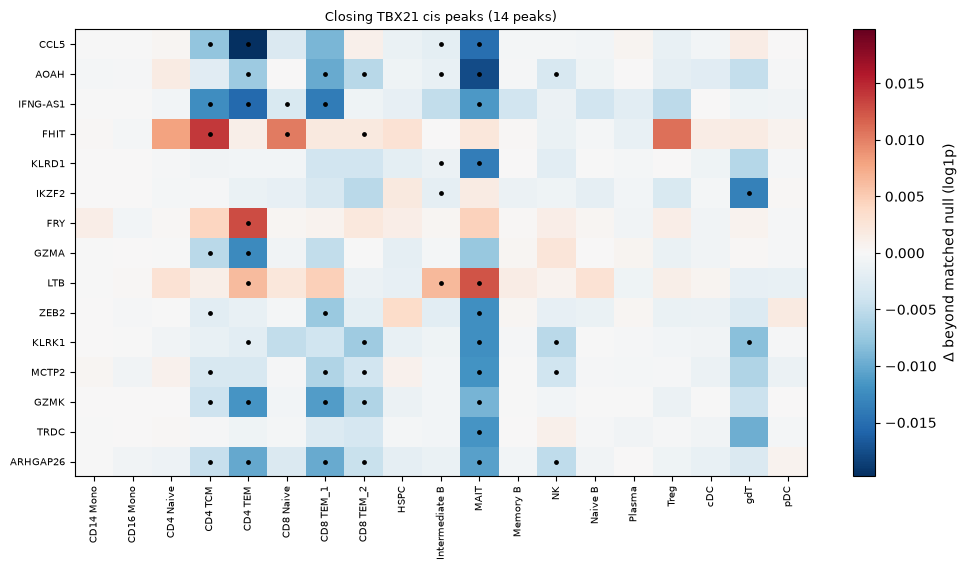

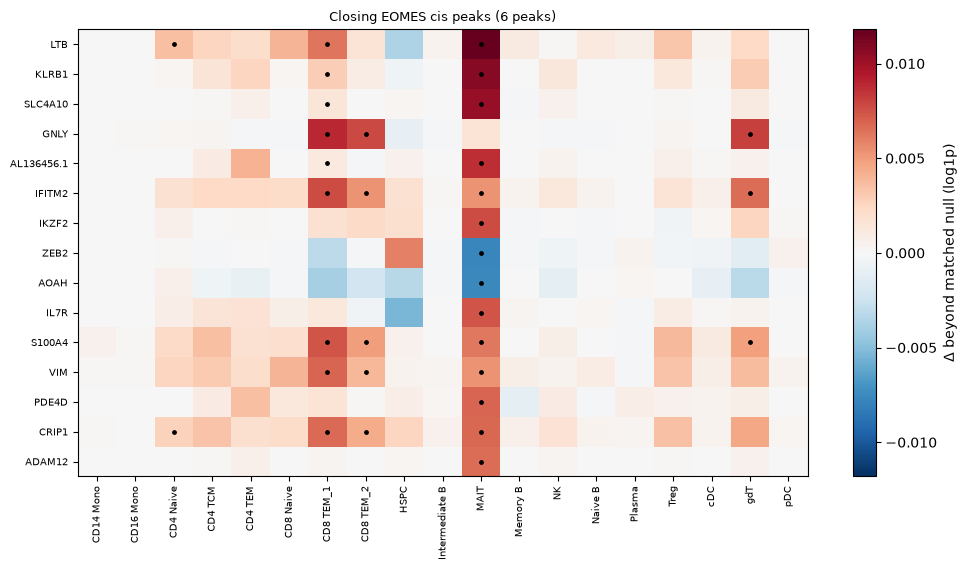

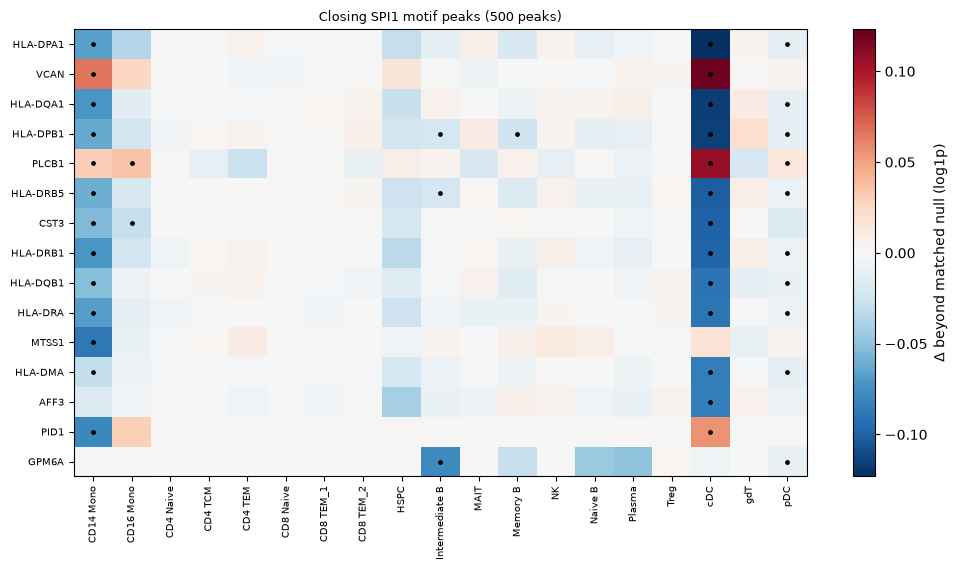

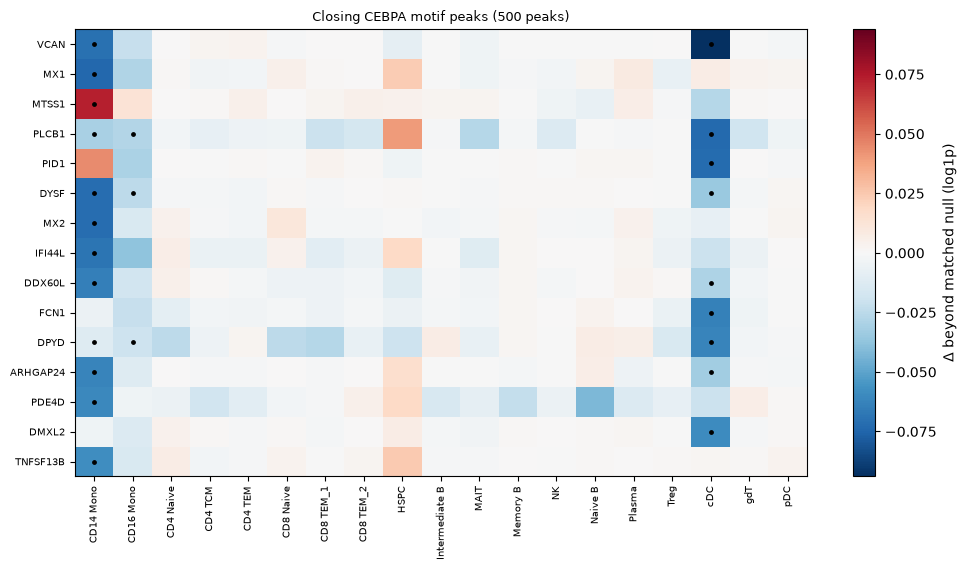

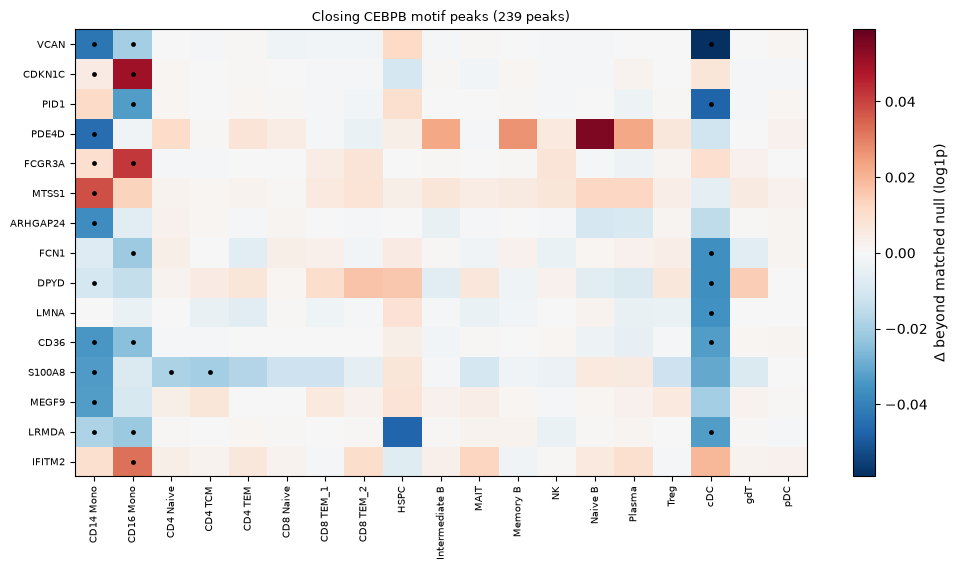

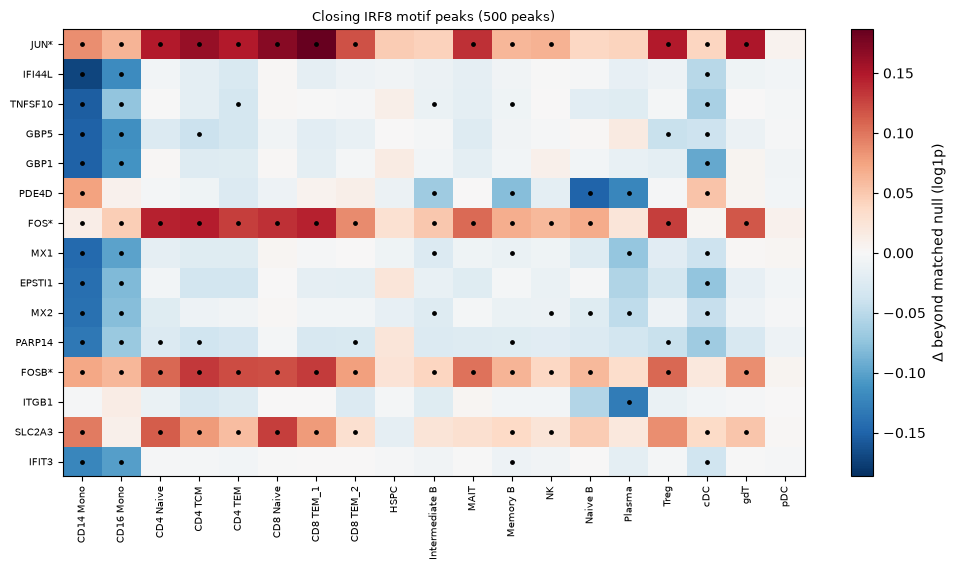

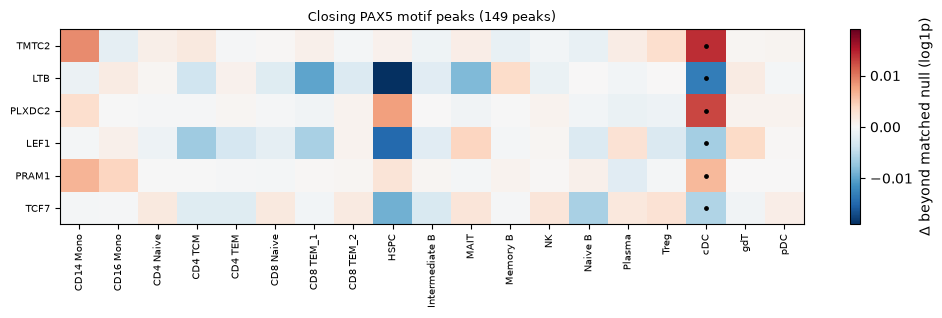

('EBF1', 'motif'): no gene passes |z| >= 3


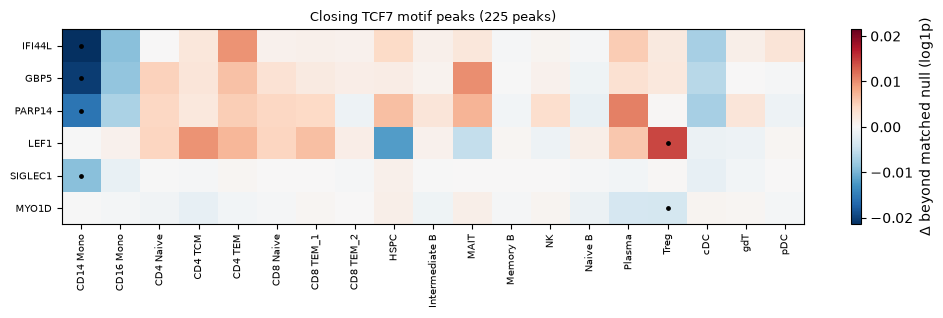

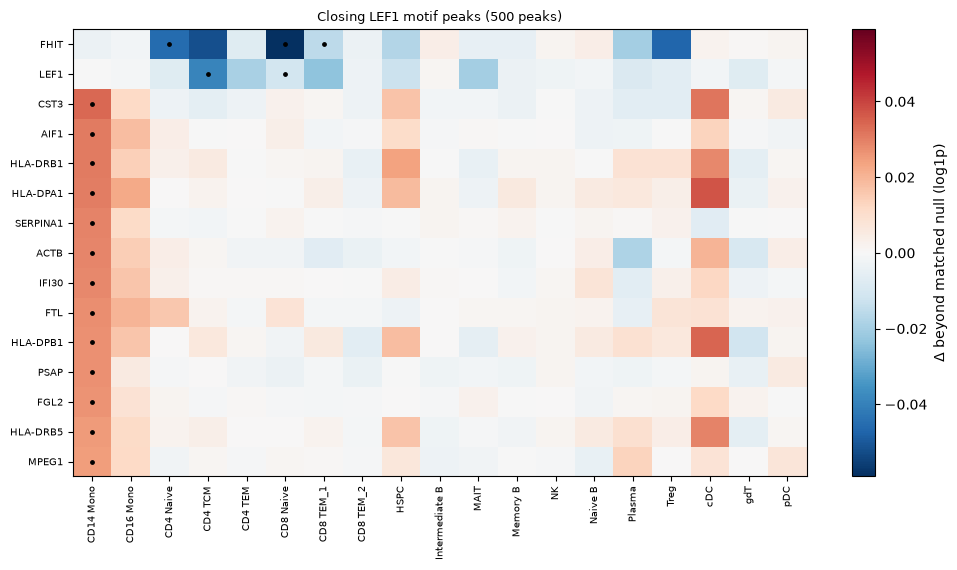

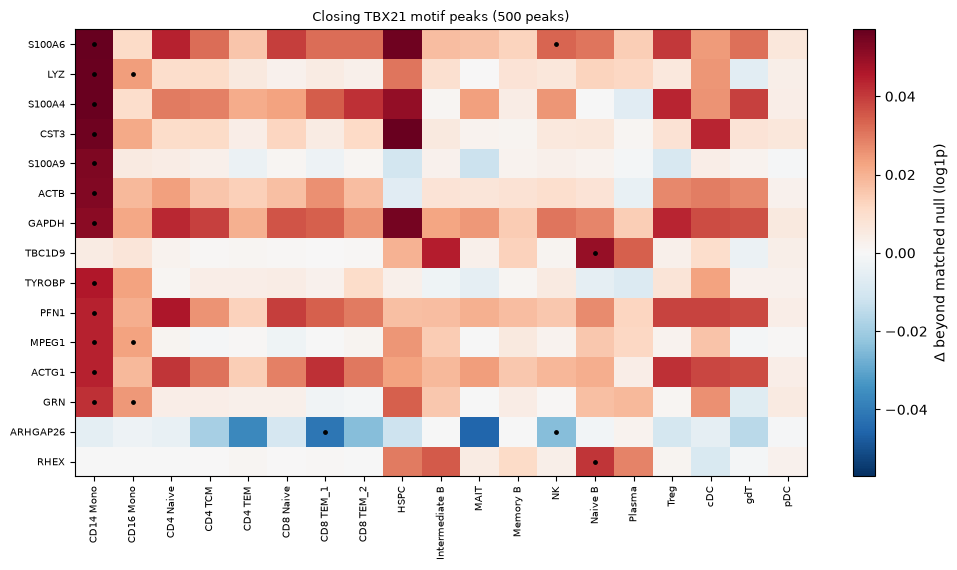

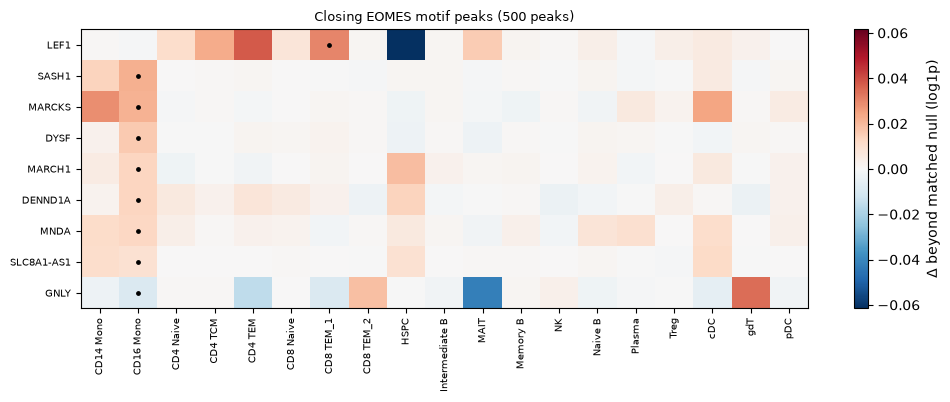

In [16]:
def top_genes(key, n=15, cell_type=None):
    """Genes with the largest excess effect among cell types where |z| >= Z_MIN."""
    e, z = excess[key].abs(), zscores[key].abs()
    if cell_type is not None:
        e, z = e.loc[[cell_type]], z.loc[[cell_type]]
    score = e.where(z >= Z_MIN).max(axis=0).dropna().sort_values(ascending=False)
    return score.index[:n]


ieg = set(IEG_GENES) & set(test_rna.var_names)


def plot_response(key, n=15):
    g = top_genes(key, n)
    if len(g) == 0:
        print(f"{key}: no gene passes |z| >= {Z_MIN:g}")
        return
    eff, z = excess[key][g].T, zscores[key][g].T
    fig, ax = plt.subplots(figsize=(0.4 * len(cell_types) + 2.5, 0.28 * len(g) + 1.6))
    lim = np.abs(eff.to_numpy()).max() or 1.0
    im = ax.imshow(eff.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    yy, xx = np.nonzero(np.abs(z.to_numpy()) >= Z_MIN)
    ax.scatter(xx, yy, s=6, c="k")
    ax.set_xticks(range(len(cell_types)), cell_types, rotation=90, fontsize=7)
    ax.set_yticks(range(len(g)), [f"{x}*" if x in ieg else x for x in g], fontsize=7)
    plt.colorbar(im, ax=ax, label="Δ beyond matched null (log1p)")
    ax.set_title(f"Closing {key[0]} {key[1]} peaks ({len(peak_sets[key])} peaks)", fontsize=9)
    plt.tight_layout()
    plt.show()


for key in peak_sets:
    plot_response(key)

### Effect size against evidence

One panel per perturbation, in the cell type that expresses the regulator most: excess effect against
moderated |z|. Labeled genes are the largest effects that pass |z| ≥ `Z_MIN` (dashed line).

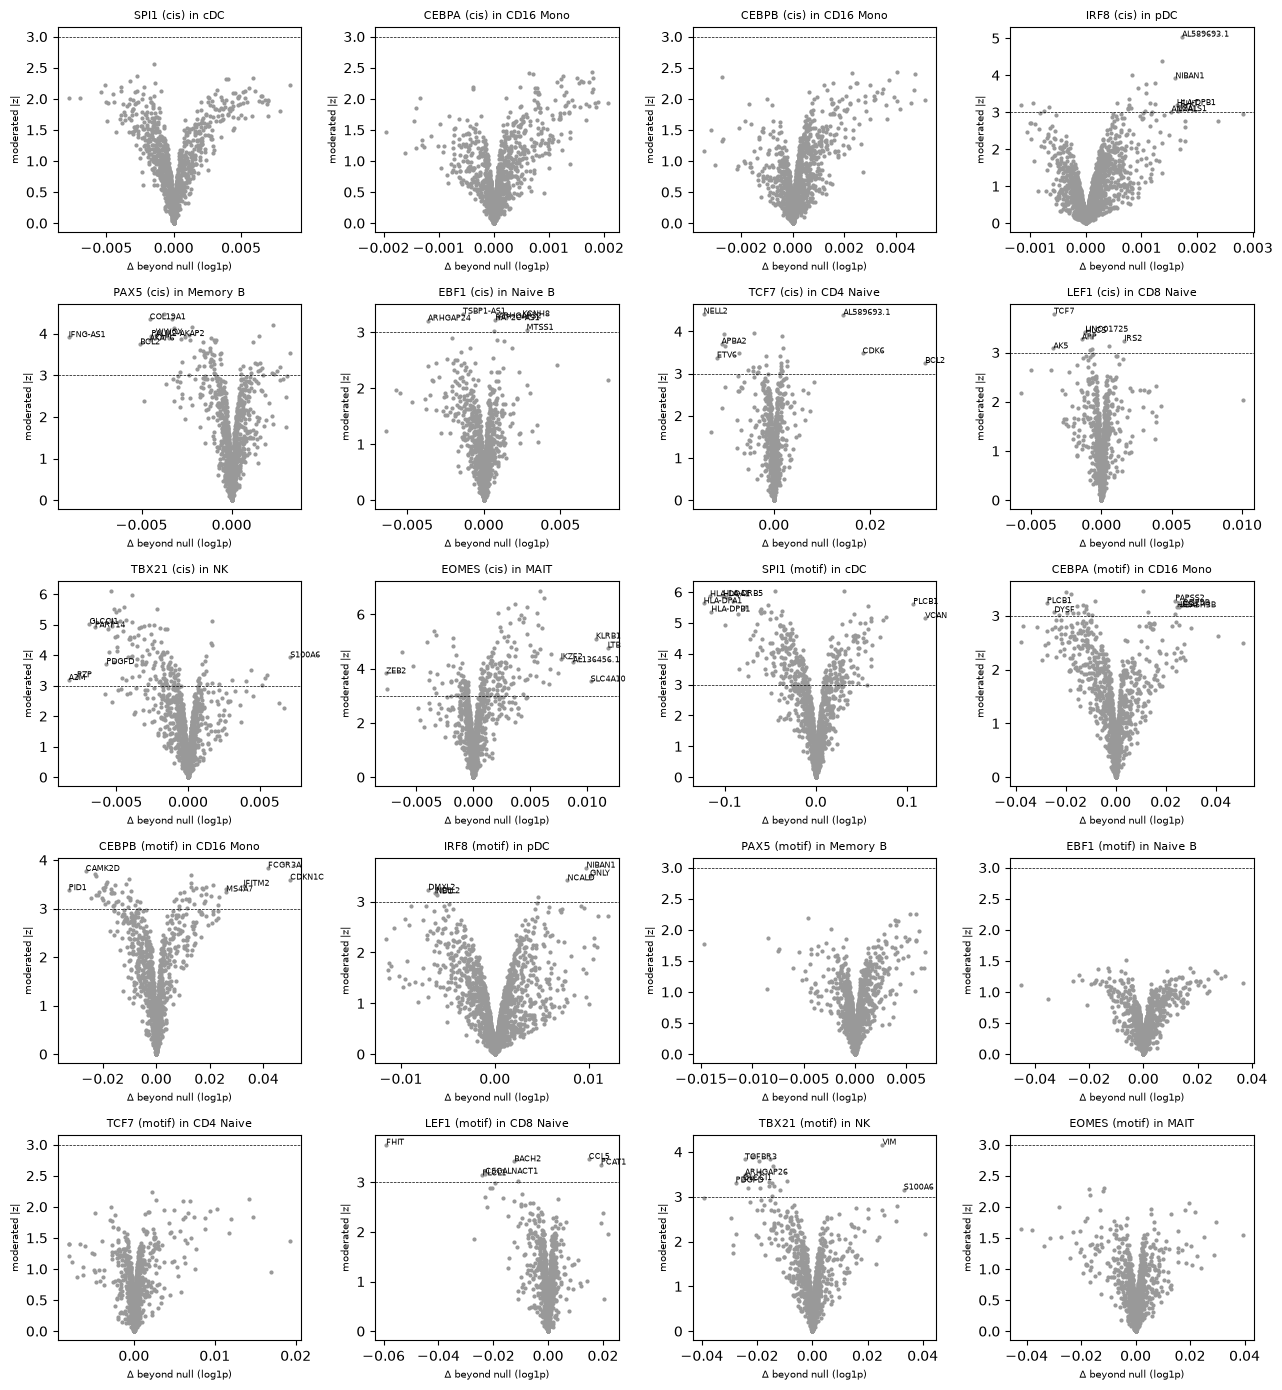

In [17]:
keys = list(peak_sets)
ncol = min(4, len(keys))
nrow = int(np.ceil(len(keys) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.8 * nrow), squeeze=False)
for ax, key in zip(axes.ravel(), keys):
    ct = gate.loc[key[0], "expressed_in_top_type"]
    x, y = excess[key].loc[ct], zscores[key].loc[ct].abs()
    ax.scatter(x, y, s=4, c="0.6")
    for gname in top_genes(key, 6, cell_type=ct):
        ax.annotate(gname + ("*" if gname in ieg else ""), (x[gname], y[gname]), fontsize=6)
    ax.axhline(Z_MIN, lw=0.5, ls="--", c="k")
    ax.set_title(f"{key[0]} ({key[1]}) in {ct}", fontsize=8)
    ax.set_xlabel("Δ beyond null (log1p)", fontsize=7)
    ax.set_ylabel("moderated |z|", fontsize=7)
for ax in axes.ravel()[len(keys):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### A stress and activation module

Genes marked `*` are immediate-early genes (FOS, JUN, EGR1, NR4A and others, listed in `IEG_GENES`).
They respond within minutes to cell handling, and in single-cell data they form a well-known
dissociation and activation signature (van den Brink et al., 2017). If the model has linked that state
to accessibility, closing many peaks can move cells along it, and such genes can then dominate the
rankings of several unrelated regulators. The table shows, for every perturbation in the regulator's
most relevant cell type, the mean excess effect on the expressed immediate-early genes and the share of
the top 20 ranked genes that are immediate-early genes. A regulator whose strongest effects are mostly
this module is telling you about the model's stress axis, not about the regulator's program.

In [18]:
rows = []
ieg_list = sorted(ieg)
for key in peak_sets:
    ct = gate.loc[key[0], "expressed_in_top_type"]
    top = list(top_genes(key, 20, cell_type=ct))
    rows.append({"perturbation": f"{key[0]} ({key[1]})", "cell_type": ct,
                 "mean excess, immediate-early genes": excess[key].loc[ct, ieg_list].mean() if ieg_list else np.nan,
                 "mean |excess|, all genes": excess[key].loc[ct].abs().mean(),
                 "share of top 20 that are immediate-early": np.mean([g in ieg for g in top]) if top else np.nan,
                 "n top genes": len(top)})
ieg_table = pd.DataFrame(rows).set_index("perturbation")
print(f"{len(ieg_list)} of {len(IEG_GENES)} immediate-early genes are model features")
ieg_table.round(4)

10 of 24 immediate-early genes are model features


,cell_type,"mean excess, immediate-early genes","mean |excess|, all genes",share of top 20 that are immediate-early,n top genes
perturbation,,,,,
SPI1 (cis),cDC,0.0008,0.0006,NaN,0
CEBPA (cis),CD16 Mono,0.0002,0.0002,NaN,0
CEBPB (cis),CD16 Mono,-0.0012,0.0003,NaN,0
IRF8 (cis),pDC,0.0002,0.0002,0.0,20
PAX5 (cis),Memory B,0.0009,0.0003,0.0,20
EBF1 (cis),Naive B,-0.0001,0.0003,0.0,7
TCF7 (cis),CD4 Naive,-0.0019,0.0005,0.0,20
LEF1 (cis),CD8 Naive,0.0017,0.0002,0.0,10
TBX21 (cis),NK,-0.0012,0.0005,0.0,20


### Per-cell view

The mean hides which cells respond. Coloring the test-cell UMAP by the per-cell change in the
regulator's own predicted expression shows where the model places the response.

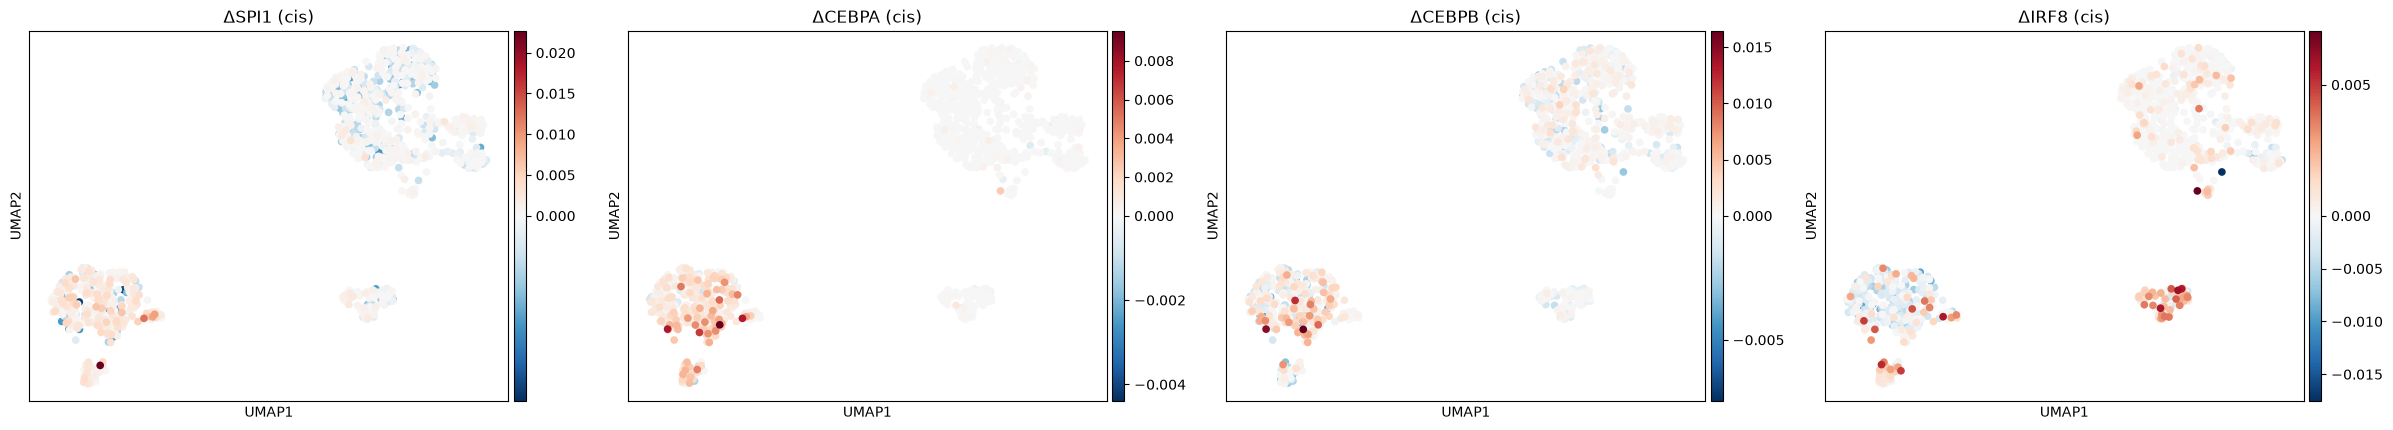

In [19]:
show = [k for k in peak_sets][:4]
for key in show:
    test_rna.obs[f"Δ{key[0]} ({key[1]})"] = deltas[key][:, test_rna.var_names.get_loc(key[0])]
sc.pl.umap(test_rna, color=[f"Δ{k[0]} ({k[1]})" for k in show], cmap="RdBu_r", vcenter=0, ncols=4)

## 9. Where on the genome?

### Genome-wide effect maps

Each point is a gene placed at its TSS along the concatenated chromosomes; its height is the excess
effect (beyond the matched null) of closing the regulator's peaks, in the cell type that expresses the
regulator most. Genes passing |z| ≥ `Z_MIN` are colored (red up, blue down) and the largest are named
(`*` marks immediate-early genes). The ticks under the axis are the closed peaks, and the triangle marks
the regulator's own gene. A regulator whose closed peaks cluster near responding genes, rather than
spreading evenly, is one whose model effects have a local component.

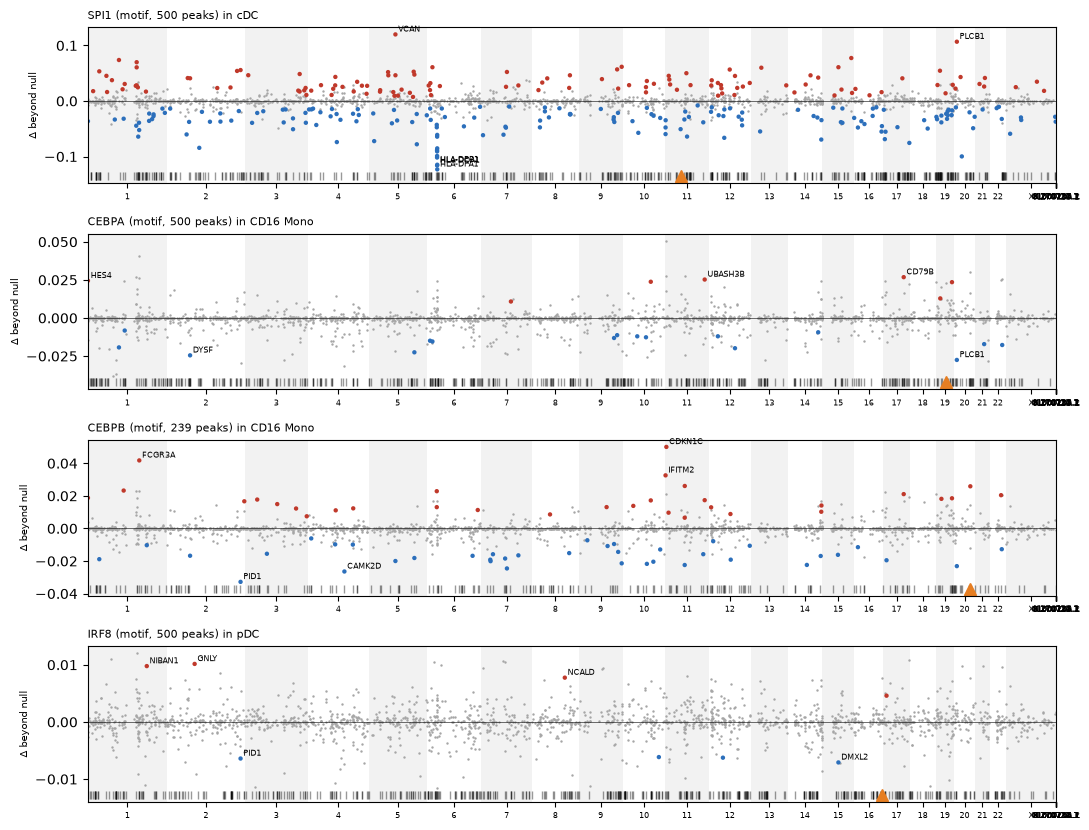

In [20]:
def chrom_order(names):
    def key(c):
        c = str(c).replace("chr", "")
        return (0, int(c)) if c.isdigit() else (1, {"X": 23, "Y": 24, "M": 25, "MT": 25}.get(c, 99), c)
    return sorted(set(map(str, names)), key=key)


gene_pos = tss.reindex(test_rna.var_names).dropna(subset=["chrom"])
chroms_g = [c for c in chrom_order(peaks_all["chrom"]) if c in set(gene_pos["chrom"]) or c in set(peaks_all["chrom"])]
chrom_len = pd.concat([peaks_all.groupby("chrom")["end"].max(), gene_pos.groupby("chrom")["tss"].max()], axis=1).max(axis=1)
chrom_len = chrom_len.reindex(chroms_g).fillna(0)
offset = pd.Series(np.r_[0, np.cumsum(chrom_len.to_numpy())[:-1]], index=chroms_g)
gene_x = gene_pos["tss"] + gene_pos["chrom"].map(offset)
peak_mid_all = (peaks_all["start"] + peaks_all["end"]) // 2
peak_x = peak_mid_all + peaks_all["chrom"].map(offset)


def genome_axis(ax):
    for i, c in enumerate(chroms_g):
        if i % 2 == 0:
            ax.axvspan(offset[c], offset[c] + chrom_len[c], color="0.95", lw=0)
    ax.set_xticks([offset[c] + chrom_len[c] / 2 for c in chroms_g], [c.replace("chr", "") for c in chroms_g], fontsize=6)
    ax.set_xlim(0, offset.iloc[-1] + chrom_len.iloc[-1])


def manhattan(ax, key):
    tf, kind = key
    ct = gate.loc[tf, "expressed_in_top_type"]
    e, z = excess[key].loc[ct].reindex(gene_x.index), zscores[key].loc[ct].reindex(gene_x.index).abs()
    genome_axis(ax)
    hit = z >= Z_MIN
    ax.scatter(gene_x[~hit], e[~hit], s=3, c="0.65", lw=0)
    ax.scatter(gene_x[hit], e[hit], s=10, c=np.where(e[hit] > 0, "#c0392b", "#2c6fbb"), lw=0)
    for g in e[hit].abs().sort_values(ascending=False).index[:5]:
        ax.annotate(g + ("*" if g in ieg else ""), (gene_x[g], e[g]), fontsize=6, xytext=(2, 2), textcoords="offset points")
    lo = ax.get_ylim()[0]
    ax.plot(peak_x.loc[peak_sets[key]], np.full(len(peak_sets[key]), lo), "|", c="k", ms=6, alpha=0.4)
    if tf in gene_x.index:
        ax.plot(gene_x[tf], lo, marker="^", c="#e67e22", ms=8)
    ax.axhline(0, c="k", lw=0.4)
    ax.set_ylabel("Δ beyond null", fontsize=7)
    ax.set_title(f"{tf} ({kind}, {len(peak_sets[key])} peaks) in {ct}", fontsize=8, loc="left")


show_keys = ([k for k in peak_sets if k[1] == "motif"] or list(peak_sets))[:4]
fig, axes = plt.subplots(len(show_keys), 1, figsize=(11, 2.1 * len(show_keys)), squeeze=False)
for ax, key in zip(axes[:, 0], show_keys):
    manhattan(ax, key)
plt.tight_layout()
plt.show()

### A chromosome view of one perturbation

The same information for the first perturbation above, drawn along each chromosome: closed peaks as
ticks above the chromosome, genes passing |z| ≥ `Z_MIN` as dots below it (size = |excess effect|).

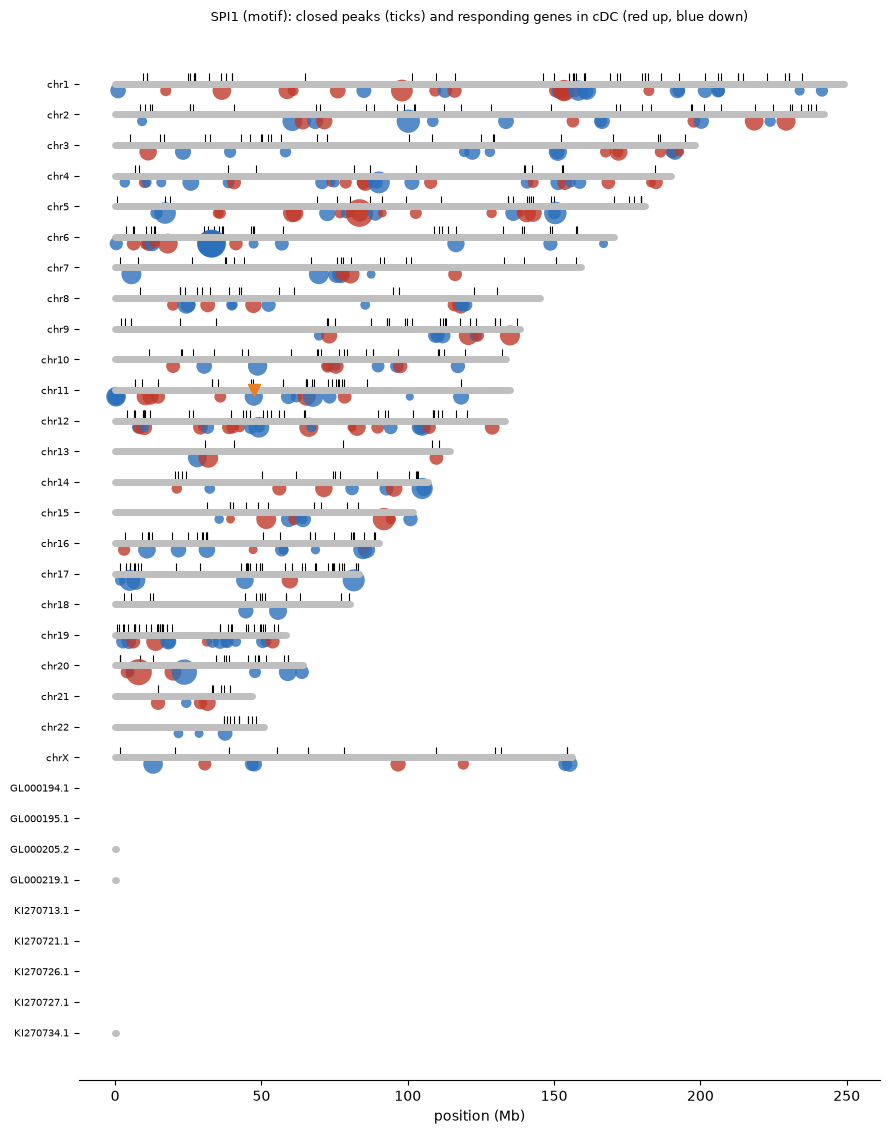

In [21]:
key = show_keys[0]
tf, kind = key
ct = gate.loc[tf, "expressed_in_top_type"]
e, z = excess[key].loc[ct], zscores[key].loc[ct].abs()
hits = [g for g in e.index if z[g] >= Z_MIN and g in gene_pos.index]
fig, ax = plt.subplots(figsize=(9, 0.32 * len(chroms_g) + 1.2))
for i, c in enumerate(chroms_g):
    y = -i
    ax.plot([0, chrom_len[c] / 1e6], [y, y], c="0.75", lw=5, solid_capstyle="round")
    pk = peaks_all.loc[[p_ for p_ in peak_sets[key] if peaks_all.loc[p_, "chrom"] == c]]
    ax.scatter(((pk["start"] + pk["end"]) / 2e6).to_numpy(), np.full(len(pk), y + 0.22), marker="|", s=40, c="k", lw=0.8)
    gh = [g for g in hits if gene_pos.loc[g, "chrom"] == c]
    if gh:
        ax.scatter(gene_pos.loc[gh, "tss"] / 1e6, np.full(len(gh), y - 0.22), s=8 + 400 * e[gh].abs() / (e[hits].abs().max() + 1e-12),
                   c=np.where(e[gh] > 0, "#c0392b", "#2c6fbb"), alpha=0.8, lw=0)
    if tf in gene_pos.index and gene_pos.loc[tf, "chrom"] == c:
        ax.plot(gene_pos.loc[tf, "tss"] / 1e6, y, marker="v", c="#e67e22", ms=9)
ax.set_yticks([-i for i in range(len(chroms_g))], chroms_g, fontsize=7)
ax.set_xlabel("position (Mb)")
ax.set_title(f"{tf} ({kind}): closed peaks (ticks) and responding genes in {ct} (red up, blue down)", fontsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

### An in-silico tiling screen around each regulator

CRISPRi tiling screens silence one region at a time along a locus and read out a gene's expression. The
model version: every model peak within `TILING_WINDOW_BP` of a regulator's TSS is closed **alone**, and
the change in the regulator's own predicted expression in its top cell type is recorded. To calibrate,
`N_TILING_NULL` random single peaks from elsewhere in the genome are closed the same way; a peak whose
effect lies beyond 99% of those random single-peak effects is highlighted and linked to the TSS by an
arc. Single peaks move a 30-dimensional latent state only slightly, so expect small numbers; the question
is which peaks stand out, not how large they are.

In [22]:
window = {}
for tf in panel:
    same = peaks_all.loc[model_peaks, "chrom"].to_numpy() == tss.loc[tf, "chrom"]
    rel = (peak_mid_all.loc[model_peaks].to_numpy() - int(tss.loc[tf, "tss"]))
    sel = same & (np.abs(rel) <= TILING_WINDOW_BP)
    window[tf] = pd.Series(rel[sel], index=np.array(model_peaks)[sel])
union = sorted(set().union(*[set(w.index) for w in window.values()]))
targets = [(tf, gate.loc[tf, "expressed_in_top_type"]) for tf in panel]
ct_pos = cell_types.get_indexer([ct for _, ct in targets])
g_pos = test_rna.var_names.get_indexer([tf for tf, _ in targets])


def single_peak_effects(cols):
    out = np.zeros((len(cols), len(targets)))
    for i, c in enumerate(cols):
        eff = by_type(closed_delta(np.array([c]))).to_numpy()
        out[i] = eff[ct_pos, g_pos]
    return out


tile = pd.DataFrame(single_peak_effects(name_to_col[union].to_numpy()), index=union, columns=[t for t, _ in targets])
in_window = set(union)
null_pool = np.setdiff1d(np.arange(len(model_peaks)), name_to_col[list(in_window)].to_numpy())
null_cols = np.random.default_rng(5).choice(null_pool, size=min(N_TILING_NULL, len(null_pool)), replace=False)
tile_null = pd.DataFrame(single_peak_effects(null_cols), columns=[t for t, _ in targets])
thresh = tile_null.abs().quantile(0.99)
print(f"{len(union)} peaks screened in {len(panel)} windows; {len(null_cols)} random single peaks as null")

274 peaks screened in 10 windows; 200 random single peaks as null


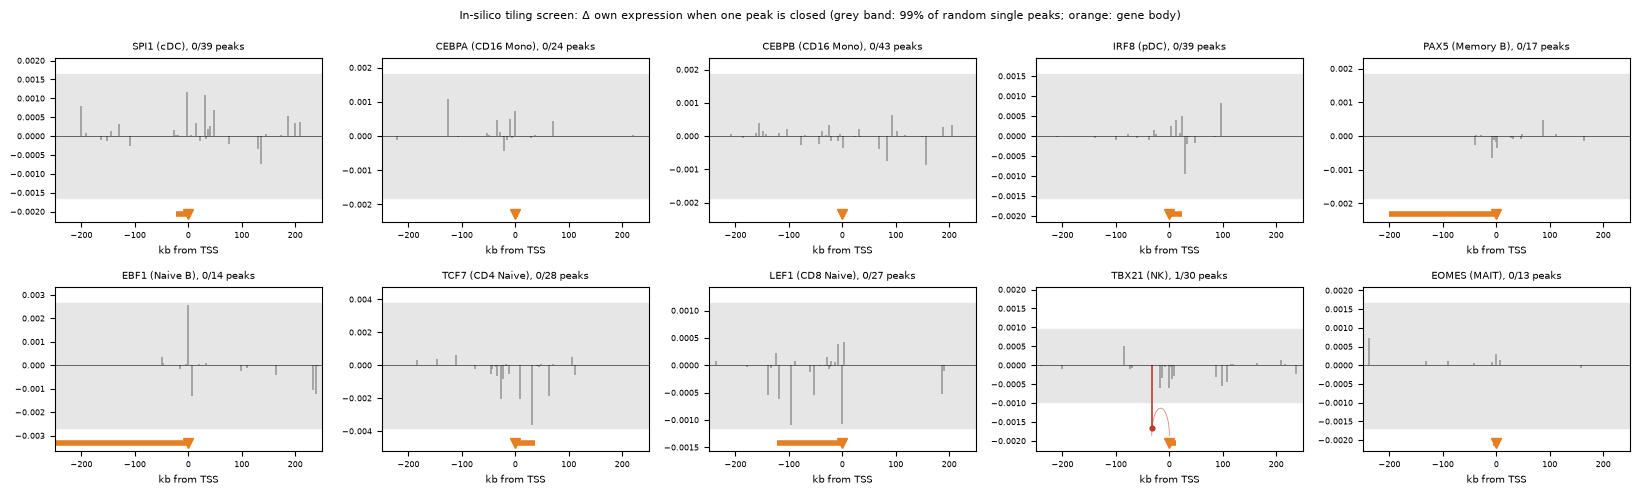

In [23]:
has_body = {"chromStart", "chromEnd", "strand"} <= set(rna.var.columns)
ncol = min(5, len(panel))
nrow = int(np.ceil(len(panel) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.3 * ncol, 2.5 * nrow), squeeze=False)
for ax, tf in zip(axes.ravel(), panel):
    w = window[tf]
    eff = tile.loc[w.index, tf]
    sig = eff.abs() > thresh[tf]
    x = w.to_numpy() / 1e3
    ax.vlines(x, 0, eff.to_numpy(), color=np.where(sig, "#c0392b", "0.6"), lw=1.2)
    ax.scatter(x[sig.to_numpy()], eff[sig].to_numpy(), s=12, c="#c0392b", zorder=3)
    top = max(np.abs(eff).max(), thresh[tf]) * 1.25 if len(eff) else thresh[tf] * 1.25
    for xi in x[sig.to_numpy()]:                                        # arcs from significant peaks to the TSS
        t = np.linspace(0, np.pi, 30)
        ax.plot(xi / 2 + (xi / 2) * np.cos(t), -0.9 * top + 0.35 * top * np.sin(t) * np.sign(1), c="#c0392b", lw=0.6, alpha=0.6)
    ax.axhspan(-thresh[tf], thresh[tf], color="0.9", zorder=0)
    if has_body and pd.notna(rna.var.loc[tf, "chromStart"]):
        g0, g1 = (float(rna.var.loc[tf, "chromStart"]) - tss.loc[tf, "tss"]) / 1e3, (float(rna.var.loc[tf, "chromEnd"]) - tss.loc[tf, "tss"]) / 1e3
        ax.plot([g0, g1], [-top, -top], c="#e67e22", lw=4, solid_capstyle="butt")
    ax.plot(0, -top, marker="v", c="#e67e22", ms=7)
    ax.set_ylim(-top * 1.1, top)
    ax.set_xlim(-TILING_WINDOW_BP / 1e3, TILING_WINDOW_BP / 1e3)
    ax.axhline(0, c="k", lw=0.4)
    ax.set_title(f"{tf} ({gate.loc[tf, 'expressed_in_top_type']}), {int(sig.sum())}/{len(eff)} peaks", fontsize=7)
    ax.set_xlabel("kb from TSS", fontsize=7)
    ax.tick_params(labelsize=6)
for ax in axes.ravel()[len(panel):]:
    ax.axis("off")
fig.suptitle("In-silico tiling screen: Δ own expression when one peak is closed (grey band: 99% of random single peaks; orange: gene body)",
             fontsize=8)
plt.tight_layout()
plt.show()

Pooled over regulators: the effect of a single peak, in units of its regulator's null (|Δ| divided by the
99th percentile of random single-peak |Δ|), against its distance from the TSS. A model with a genuine cis
component would show larger effects close to the TSS than far from it.

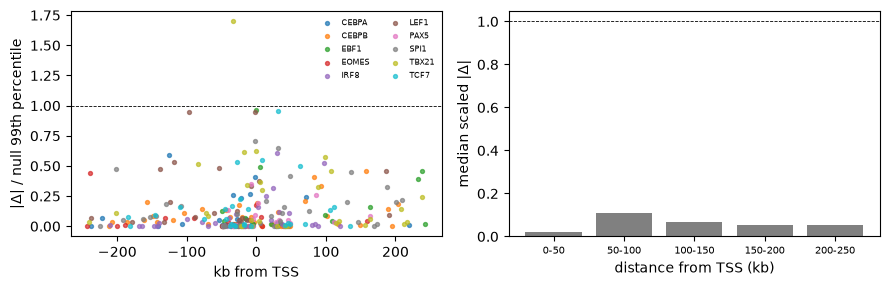

In [24]:
pooled = pd.concat([pd.DataFrame({"kb": window[tf].to_numpy() / 1e3,
                                  "scaled": (tile.loc[window[tf].index, tf].abs() / (thresh[tf] + 1e-12)).to_numpy(),
                                  "regulator": tf}) for tf in panel if len(window[tf])], ignore_index=True)
if len(pooled):
    bins = np.linspace(-TILING_WINDOW_BP / 1e3, TILING_WINDOW_BP / 1e3, 11)
    pooled["bin"] = pd.cut(pooled["kb"].abs(), np.linspace(0, TILING_WINDOW_BP / 1e3, 6))
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    for tf, d in pooled.groupby("regulator"):
        axes[0].scatter(d["kb"], d["scaled"], s=8, alpha=0.7, label=tf)
    axes[0].axhline(1, c="k", lw=0.6, ls="--")
    axes[0].set(xlabel="kb from TSS", ylabel="|Δ| / null 99th percentile")
    axes[0].legend(fontsize=6, frameon=False, ncol=2)
    med = pooled.groupby("bin", observed=False)["scaled"].median()
    axes[1].bar(range(len(med)), med.to_numpy(), color="0.5")
    axes[1].set_xticks(range(len(med)), [f"{int(b.left)}-{int(b.right)}" for b in med.index], fontsize=7)
    axes[1].axhline(1, c="k", lw=0.6, ls="--")
    axes[1].set(xlabel="distance from TSS (kb)", ylabel="median scaled |Δ|")
    plt.tight_layout()
    plt.show()

## 10. Where do perturbed cells move in the latent space?

Encoding the edited ATAC places each perturbed cell in the latent space. Two readouts:

- **displacement**: distance between a cell's original and perturbed embedding, averaged per cell
  type, next to the same quantity for one matched random closure (`excess_over_random` is the
  difference);
- **label shift**: the fraction of cells whose nearest-neighbor cell-type label (voted by the RNA
  embeddings of the test cells) changes after the edit, and what they change to.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15).fit(z_rna, labels)   # labeled reference: RNA embeddings
before = knn.predict(z_atac)


def encode_closed(cols):
    mask = np.ones(X_test.shape[1], dtype=np.float32)
    mask[cols] = 0.0
    edited = ad.AnnData(sp.csr_matrix(X_test.multiply(mask[None, :])), obs=test["atac"].obs)
    return encode_adata(model, edited, modality="atac", device=device, latent="modality_mean")


shift_rows, transitions, changed = [], {}, {}
rng_shift = np.random.default_rng(2)
for key, peaks in peak_sets.items():
    cols = name_to_col[peaks].to_numpy()
    z_pert = encode_closed(cols)
    z_null = encode_closed(matched_random_sets(cols, 1, rng_shift)[0])
    disp = pd.Series(np.linalg.norm(z_pert - z_atac, axis=1), index=labels).groupby(level=0).mean()
    disp_null = pd.Series(np.linalg.norm(z_null - z_atac, axis=1), index=labels).groupby(level=0).mean()
    after = knn.predict(z_pert)
    transitions[key] = pd.crosstab(pd.Series(before, name="before"), pd.Series(after, name="after"))
    changed[key] = float((before != after).mean())
    shift_rows.append(pd.DataFrame({"perturbation": f"{key[0]} ({key[1]})", "cell_type": disp.index,
                                    "displacement": disp.values, "random_set": disp_null.values,
                                    "label_changed": pd.Series(before != after, index=labels)
                                    .groupby(level=0).mean().loc[disp.index].values}))
shift = pd.concat(shift_rows, ignore_index=True)
shift["excess_over_random"] = shift["displacement"] - shift["random_set"]
shift.sort_values("excess_over_random", ascending=False).head(15).round(3)

,perturbation,cell_type,displacement,random_set,label_changed,excess_over_random
247,IRF8 (motif),CD14 Mono,0.270,0.136,0.000,0.134
248,IRF8 (motif),CD16 Mono,0.214,0.103,0.000,0.111
261,IRF8 (motif),Plasma,0.223,0.115,0.000,0.108
209,CEBPA (motif),CD14 Mono,0.186,0.105,0.004,0.081
263,IRF8 (motif),cDC,0.195,0.117,0.056,0.078
251,IRF8 (motif),CD4 TEM,0.202,0.128,0.033,0.075
256,IRF8 (motif),Intermediate B,0.167,0.093,0.000,0.074
260,IRF8 (motif),Naive B,0.177,0.105,0.000,0.072
359,TBX21 (motif),gdT,0.146,0.084,0.000,0.062
258,IRF8 (motif),Memory B,0.140,0.079,0.032,0.061


Compare `excess_over_random` **across cell types** rather than with zero. If a set moves every cell
type more than a random set does, including cell types that do not use the regulator, the excess
reflects the kind of peaks in the set more than the regulator's biology. A random set is a single draw
here, so small differences are noise.

The fraction of cells whose label changes depends on how close a cell type sits to its neighbors: small
populations wedged between larger ones (for example Treg or MAIT cells) change labels more easily.

{'SPI1 (cis)': 0.001, 'CEBPA (cis)': 0.0, 'CEBPB (cis)': 0.001, 'IRF8 (cis)': 0.001, 'PAX5 (cis)': 0.0, 'EBF1 (cis)': 0.001, 'TCF7 (cis)': 0.003, 'LEF1 (cis)': 0.0, 'TBX21 (cis)': 0.002, 'EOMES (cis)': 0.001, 'SPI1 (motif)': 0.01, 'CEBPA (motif)': 0.005, 'CEBPB (motif)': 0.004, 'IRF8 (motif)': 0.011, 'PAX5 (motif)': 0.001, 'EBF1 (motif)': 0.006, 'TCF7 (motif)': 0.002, 'LEF1 (motif)': 0.003, 'TBX21 (motif)': 0.006, 'EOMES (motif)': 0.01}


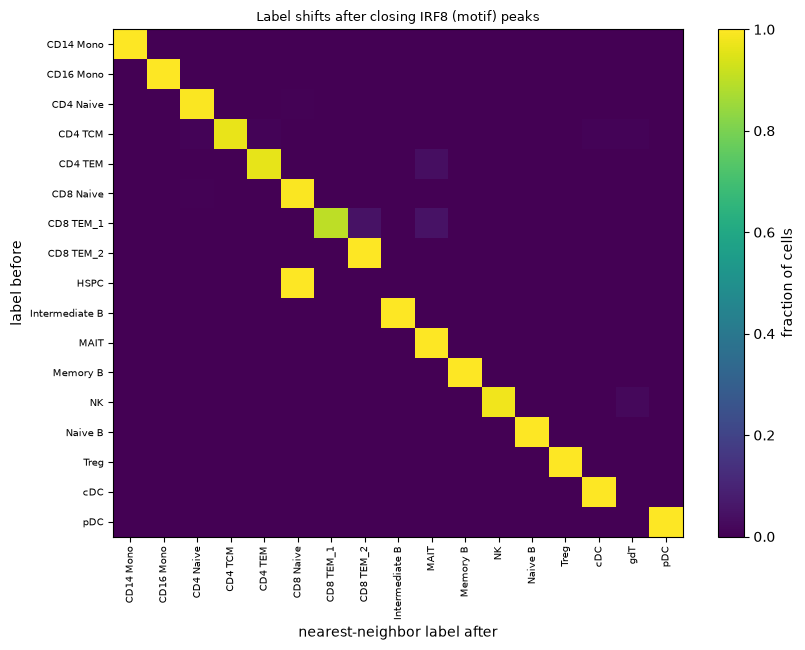

In [26]:
print({f"{k[0]} ({k[1]})": round(v, 3) for k, v in changed.items()})
key = max(changed, key=changed.get)   # the perturbation that changes the most labels
t = transitions[key]
t = t.div(t.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(0.35 * t.shape[1] + 2.5, 0.3 * t.shape[0] + 1.5))
im = ax.imshow(t.to_numpy(), cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(t.shape[1]), t.columns, rotation=90, fontsize=7)
ax.set_yticks(range(t.shape[0]), t.index, fontsize=7)
ax.set(xlabel="nearest-neighbor label after", ylabel="label before")
ax.set_title(f"Label shifts after closing {key[0]} ({key[1]}) peaks", fontsize=9)
plt.colorbar(im, ax=ax, label="fraction of cells")
plt.tight_layout()
plt.show()

## 11. Dose-response

Bernoulli inputs must stay binary, so "dose" here is the fraction of a peak set that is closed. For the
largest set, peaks are closed in order (strongest motif first for motif sets, nearest the TSS first for
cis sets), and the response of the regulator's own gene and of the perturbation's top responders is
tracked in the most relevant cell type.

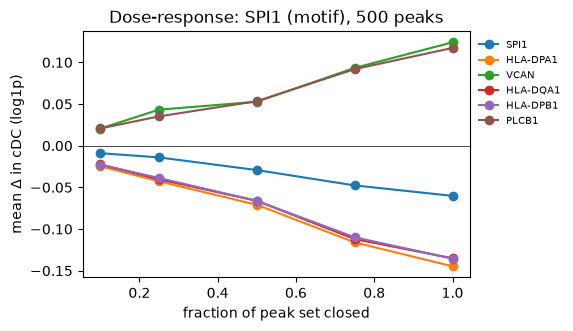

In [27]:
key = max(peak_sets, key=lambda k: len(peak_sets[k]))
tf, kind = key
ordered = list(peak_sets[key])
if kind == "motif" and motif_pvals is not None:
    ordered = list(motif_pvals.loc[ordered, tf].sort_values(kind="stable").index)
else:
    mid = (peaks_all.loc[ordered, "start"] + peaks_all.loc[ordered, "end"]) // 2
    ordered = list((mid - tss.loc[tf, "tss"]).abs().sort_values().index)
ct = gate.loc[tf, "expressed_in_top_type"]
track = list(dict.fromkeys([tf] + list(top_genes(key, 5))))
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
dose = pd.DataFrame({f: by_type(closed_delta(name_to_col[ordered[:max(1, int(f * len(ordered)))]]
                                                 .to_numpy())).loc[ct, track] for f in fractions}).T
ax = dose.plot(marker="o", figsize=(5, 3.2))
ax.axhline(0, c="k", lw=0.5)
ax.set(xlabel="fraction of peak set closed", ylabel=f"mean Δ in {ct} (log1p)",
       title=f"Dose-response: {tf} ({kind}), {len(ordered)} peaks")
ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1, 1))
plt.show()

## 12. Two regulators at once

Closing the sets of two regulators together and comparing with the sum of the single closures gives an
**interaction** term, `Δ(A+B) − Δ(A) − Δ(B)`. Zero means the model combines the two edits additively;
a large value means it does not. The pair used is the first two motif sets if available, otherwise
the first two sets.

In [28]:
motif_keys = [k for k in peak_sets if k[1] == "motif"]
pair = motif_keys[:2] if len(motif_keys) >= 2 else list(peak_sets)[:2]
if len(pair) == 2:
    a, b = pair
    both = np.union1d(name_to_col[peak_sets[a]].to_numpy(), name_to_col[peak_sets[b]].to_numpy())
    combo = by_type(closed_delta(both))
    interaction = combo - effects[a] - effects[b]
    genes_show = list(dict.fromkeys(list(top_genes(a, 6)) + list(top_genes(b, 6))))
    ct = gate.loc[a[0], "expressed_in_top_type"]
    summary = pd.DataFrame({f"{a[0]} alone": effects[a].loc[ct, genes_show],
                            f"{b[0]} alone": effects[b].loc[ct, genes_show],
                            "both": combo.loc[ct, genes_show],
                            "interaction": interaction.loc[ct, genes_show]})
    print(f"{a} + {b}, in {ct}; median |interaction| over all genes and cell types: "
          f"{np.median(np.abs(interaction.to_numpy())):.2e}")
    display(summary.round(4))

('SPI1', 'motif') + ('CEBPA', 'motif'), in cDC; median |interaction| over all genes and cell types: 6.75e-05


,SPI1 alone,CEBPA alone,both,interaction
genes,,,,
HLA-DPA1,-0.1448,0.0253,-0.1182,0.0012
VCAN,0.1241,-0.0823,0.0393,-0.0024
HLA-DQA1,-0.1352,0.0199,-0.1105,0.0048
HLA-DPB1,-0.1355,0.0203,-0.1134,0.0018
PLCB1,0.1173,-0.0514,0.0668,0.0009
HLA-DRB5,-0.1196,0.0190,-0.0972,0.0035
MX1,-0.0265,-0.0062,-0.0387,-0.0060
MTSS1,0.0276,-0.0142,0.0228,0.0094
PID1,0.0626,-0.0671,0.0030,0.0075


## 13. Does an independently trained model agree?

A result that depends on one model's idiosyncrasies should not replicate in a model with a different
ATAC representation. Here we train the paper's Multiome setup (ATAC as TF-IDF/LSI over **all** peaks,
Gaussian likelihood) on the same cells and RNA features, apply the same closures to the raw peak counts,
re-run the fitted TF-IDF/LSI transform, and decode RNA.

The comparison uses **excess** effects in both models. Raw effects share the generic response to
closing many open peaks (Section 7), so agreement between raw effects would be inflated by it. The LSI
model's null uses `N_NULL_LSI` of the same kind of matched random sets (fewer than above, because every
edit re-runs TF-IDF and LSI over all peaks). Two summaries per perturbation, in the relevant cell type:
the Spearman correlation of excess effects over all genes, and the fraction of the peak-level model's
top 20 genes whose excess effect has the same sign in the LSI model (0.5 = chance).

[2026-09-22 20:57:12,739] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-22 20:57:12,740] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-22 20:57:12,740] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-22 20:57:12,741] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-22 20:57:12,741] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-22 20:57:12,741] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-22 20:57:12,742] [UniVITrainer] [INFO]   log_every: 50
[2026-09-22 20:57:12,742] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-22 20:57:12,742] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-22 20:57:12,743] [UniVITrainer] [INFO]   seed: 0
[2026-09-22 20:57:12,743] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-22 20:57:12,743] [UniVITrainer] [INFO]   patience: 50
[2026-09-22 20:57:12,744] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-22 20:57:12,744] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-22 20:57:14,390] [Uni

LSI model, ATAC -> RNA median per-gene r: 0.276 (peak-level model: 0.270)


,cell_type,spearman_rho_excess,spearman_rho_raw,top_genes_same_sign,n_top_genes
perturbation,,,,,
SPI1 (cis),cDC,0.445,0.483,NaN,0
CEBPA (cis),CD16 Mono,0.125,0.146,NaN,0
CEBPB (cis),CD16 Mono,0.051,0.143,NaN,0
IRF8 (cis),pDC,0.286,0.099,0.850,20
PAX5 (cis),Memory B,0.307,0.284,1.000,20
EBF1 (cis),Naive B,0.449,0.399,1.000,7
TCF7 (cis),CD4 Naive,0.161,0.145,0.850,20
LEF1 (cis),CD8 Naive,0.236,0.212,0.800,10
TBX21 (cis),NK,0.214,0.240,0.950,20


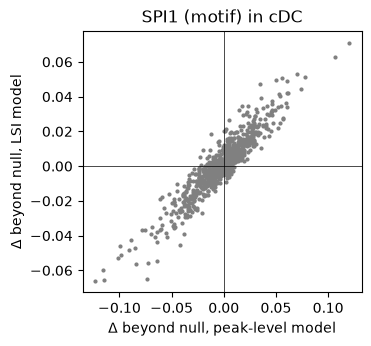

In [29]:
if RUN_LSI_COMPARISON:
    from scipy.stats import spearmanr

    atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(atac[splits["train"]])
    lsi = {k: atac_prep.transform(atac[i]) for k, i in splits.items()}
    cfg_lsi = UniVIConfig(
        latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
        kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
        modalities=[ModalityConfig("rna", train["rna"].n_vars, [512, 256, 128], [128, 256, 512]),
                    ModalityConfig("atac", lsi["train"].n_vars, [128, 64], [64, 128])])
    model_lsi = UniVIMultiModalVAE(cfg_lsi, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
    UniVITrainer(model_lsi, make_loader({"rna": train["rna"], "atac": lsi["train"]}, batch_size=BATCH_SIZE,
                                        shuffle=True, drop_last=True),
                 make_loader({"rna": val["rna"], "atac": lsi["val"]}, batch_size=1024), train_cfg).fit()

    atac_test_raw = atac[splits["test"]].copy()
    base_lsi = cross_modal_predict(model_lsi, lsi["test"], src_mod="atac", tgt_mod="rna", device=device)
    r_lsi = pd.Series(pearson_corr_per_feature(observed, base_lsi), index=test_rna.var_names)
    print(f"LSI model, ATAC -> RNA median per-gene r: {r_lsi.median():.3f} "
          f"(peak-level model: {gene_r.median():.3f})")

    def closed_delta_lsi(peaks):
        edited = atac_test_raw.copy()
        counts = sp.csr_matrix(edited.layers["counts"], dtype=np.float32)
        mask = np.ones(counts.shape[1], dtype=np.float32)
        mask[edited.var_names.get_indexer(peaks)] = 0.0
        edited.layers["counts"] = sp.csr_matrix(counts.multiply(mask[None, :]))
        pred = cross_modal_predict(model_lsi, atac_prep.transform(edited), src_mod="atac", tgt_mod="rna",
                                   device=device)
        return pred - base_lsi

    rows = []
    effects_lsi, excess_lsi = {}, {}
    rng_lsi = np.random.default_rng(3)
    for key, peaks in peak_sets.items():
        effects_lsi[key] = by_type(closed_delta_lsi(peaks))
        null = np.mean([by_type(closed_delta_lsi([model_peaks[c] for c in cols])).to_numpy()
                        for cols in matched_random_sets(name_to_col[peaks].to_numpy(), N_NULL_LSI, rng_lsi)], axis=0)
        excess_lsi[key] = effects_lsi[key] - null
        ct = gate.loc[key[0], "expressed_in_top_type"]
        top = top_genes(key, 20, cell_type=ct)
        rows.append({"perturbation": f"{key[0]} ({key[1]})", "cell_type": ct,
                     "spearman_rho_excess": spearmanr(excess[key].loc[ct], excess_lsi[key].loc[ct]).statistic,
                     "spearman_rho_raw": spearmanr(effects[key].loc[ct], effects_lsi[key].loc[ct]).statistic,
                     "top_genes_same_sign": (np.sign(excess[key].loc[ct, top]) ==
                                             np.sign(excess_lsi[key].loc[ct, top])).mean() if len(top) else np.nan,
                     "n_top_genes": len(top)})
    agreement = pd.DataFrame(rows).set_index("perturbation")
    display(agreement.round(3))

    key = agreement["spearman_rho_excess"].idxmax() if agreement["spearman_rho_excess"].notna().any() else None
    if key is not None:
        k = next(k for k in peak_sets if f"{k[0]} ({k[1]})" == key)
        ct = gate.loc[k[0], "expressed_in_top_type"]
        fig, ax = plt.subplots(figsize=(3.6, 3.4))
        ax.scatter(excess[k].loc[ct], excess_lsi[k].loc[ct], s=4, c="0.5")
        ax.axhline(0, lw=0.5, c="k")
        ax.axvline(0, lw=0.5, c="k")
        ax.set(xlabel="Δ beyond null, peak-level model", ylabel="Δ beyond null, LSI model", title=f"{key} in {ct}")
        plt.show()

## 14. Save the results

One long table with every perturbation, cell type and gene: observed mean change, null mean and s.d.,
excess effect, moderated z and the unmoderated z (`z_raw`). Filter it rather than re-running the
notebook; sorting by `excess` among rows with |z| ≥ `Z_MIN` reproduces the rankings above.

In [30]:
long = []
for key in peak_sets:
    df = pd.DataFrame({"delta": effects[key].stack(), "null_mean": null_mean[key].stack(),
                       "null_sd": null_sd[key].stack(), "excess": excess[key].stack(), "z": zscores[key].stack(),
                       "z_raw": (excess[key] / (null_sd[key] + 1e-12)).stack()})
    df.index.names = ["cell_type", "gene"]
    df = df.reset_index()
    df.insert(0, "set", key[1])
    df.insert(0, "regulator", key[0])
    df["n_peaks"] = len(peak_sets[key])
    long.append(df)
results = pd.concat(long, ignore_index=True)
results["immediate_early_gene"] = results["gene"].isin(ieg)
results.to_csv(out_dir / "tf_perturbation_effects.csv.gz", index=False)
print("written:", out_dir / "tf_perturbation_effects.csv.gz")
passing = results[results["z"].abs() >= Z_MIN]
passing.reindex(passing["excess"].abs().sort_values(ascending=False).index).head(20).round(4)

written: univi_outputs\tf_perturbation_effects.csv.gz


,regulator,set,cell_type,gene,delta,null_mean,null_sd,excess,z,z_raw,n_peaks,immediate_early_gene
506804,IRF8,motif,CD8 TEM_1,JUN,0.1835,-0.0030,0.0384,0.1865,4.7514,4.8561,500,True
494805,IRF8,motif,CD14 Mono,IFI44L,-0.1928,-0.0217,0.0214,-0.1711,-7.8445,-8.0082,500,False
504801,IRF8,motif,CD8 Naive,JUN,0.1688,-0.0004,0.0385,0.1692,4.3133,4.3955,500,True
500795,IRF8,motif,CD4 TCM,JUN,0.1696,0.0075,0.0344,0.1621,4.6113,4.7104,500,True
495189,IRF8,motif,CD14 Mono,TNFSF10,-0.1726,-0.0195,0.0156,-0.1531,-9.5531,-9.8265,500,False
494816,IRF8,motif,CD14 Mono,GBP5,-0.1647,-0.0133,0.0160,-0.1515,-9.2343,-9.4924,500,False
494815,IRF8,motif,CD14 Mono,GBP1,-0.1755,-0.0244,0.0167,-0.1512,-8.7978,-9.0322,500,False
528837,IRF8,motif,gdT,JUN,0.1493,-0.0016,0.0272,0.1510,5.3547,5.5471,500,True
521405,IRF8,motif,Naive B,PDE4D,-0.1679,-0.0189,0.0393,-0.1491,-3.6941,-3.7977,500,False
524831,IRF8,motif,Treg,JUN,0.1498,0.0012,0.0355,0.1486,4.0693,4.1848,500,True


## Reading the results

- **Start from the gate.** Regulators whose expression is poorly predicted from ATAC (Section 4) cannot
  give informative cis readouts, whatever their z-scores.
- **Read effects against the null, not zero.** The matched null is often shifted (Section 7); the excess
  effect is the quantity to report, and cis effects are expected to be small (Section 5).
- **Prefer effects that pass the null and replicate.** An effect with large |z| that also has the same
  sign in the LSI model (Section 13) is a better lead than one that appears in a single model. Training a
  second seed of the peak-level model is an inexpensive further check.
- **Motif sets are family-level.** Overlapping motifs mean that a "SPI1 motif" perturbation also removes
  sites of related ETS factors.
- **Separate the stress axis.** When immediate-early genes lead a regulator's ranking (Section 8), report
  them separately or exclude them before interpreting the remaining genes.
- **The model knows only co-variation.** It has learned which accessibility patterns accompany which
  expression patterns across cell types. Closing a set of peaks can therefore move a cell toward another
  cell type's profile (Section 10) without that being what a real perturbation would do.

Ideas to extend this notebook: use cell-type-specific peak subsets, perturb with `mode="set", value=1`
(opening peaks rather than closing them), or run the same analysis on the TEA-seq data to read out
predicted surface protein as well as RNA.